In [19]:
from img2table.document import Image
from img2table.ocr import TesseractOCR
from pytesseract import pytesseract
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
import cv2
img = cv2.imread(r"D:\Programming\Projects\Learning python librairies\OCR\cropped_tables\table_1.png", cv2.IMREAD_GRAYSCALE)
img = cv2.bitwise_not(img)
cv2.imwrite("Not binary image.png", img)
tables = Image(src=r"D:\Programming\Projects\Learning python librairies\OCR\Not binary image.png").extract_tables(ocr = TesseractOCR(lang="eng", tessdata_dir=r"E:\New program files\Tesseract\tessdata"), implicit_rows=False, implicit_columns=False)
tables

[]

In [20]:
def extract_dict_from_image(input_path_image, output_path_csv):  # Must In binary

    img = cv2.imread(
        input_path_image,
        cv2.IMREAD_GRAYSCALE
    )

    horizontal_kernel_size = max(
        50,
        img.shape[1] // 50
    )

    horizontal_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (horizontal_kernel_size, 1)
    )

    vertical_kernel_size = max(
        50,
        img.shape[0] // 50
    )

    vertical_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (1, vertical_kernel_size)
    )

    horizontal_lines = cv2.morphologyEx(
        img,
        cv2.MORPH_OPEN,
        horizontal_kernel
    )

    vertical_lines = cv2.morphologyEx(
        img,
        cv2.MORPH_OPEN,
        vertical_kernel
    )

    # ==========================================
    # Detect row positions
    # ==========================================

    row_projection = np.sum(
        horizontal_lines > 0,
        axis=1
    )

    row_positions = np.where(
        row_projection > 0
    )[0]

    number_of_rows = len(
        set(
            row_positions +
            range(len(row_positions), 0, -1)
        )
    ) - 1

    # ==========================================
    # Detect column positions
    # ==========================================

    column_projection = np.sum(
        vertical_lines > 0,
        axis=0
    )

    column_positions = np.where(
        column_projection > 0
    )[0]

    number_of_columns = len(
        set(
            column_positions +
            range(len(column_positions), 0, -1)
        )
    ) - 1

    print(
        f"Number of rows: {number_of_rows}, "
        f"Number of columns: {number_of_columns}"
    )

    # ==========================================
    # Detect intersections
    # ==========================================

    intersection = cv2.bitwise_and(
        vertical_lines,
        horizontal_lines
    )

    contours, _ = cv2.findContours(
        intersection,
        cv2.RETR_LIST,
        cv2.CHAIN_APPROX_SIMPLE
    )

    rectangle_boundaries = [
        cv2.boundingRect(contour)
        for contour in contours
    ]

    # ==========================================
    # Check header by merged cell
    # ==========================================

    is_header = False

    if 1 <= (
        ((number_of_rows + 1) *
         (number_of_columns + 1))
        - len(rectangle_boundaries)
    ):
        is_header = True

    # ==========================================
    # Store fitted lines
    # ==========================================

    test = np.zeros((1500, 1500))

    horizontal_fit_lines = defaultdict(list)
    vertical_fit_lines = defaultdict(list)

    horizontals = []

    for contour in contours:

        sumx = 0
        sumy = 0

        for position in contour:

            x, y = position[0]

            sumx += x
            sumy += y

        x_center = sumx // 4
        y_center = sumy // 4

        horizontal_fit_lines[y_center].append(
            x_center
        )

        vertical_fit_lines[x_center].append(
            y_center
        )

        horizontals.append(y_center)

    # ==========================================
    # Sort horizontal positions
    # ==========================================

    horizontals.sort()

    # Remove duplicate horizontal positions
    horizontals = list(
        dict.fromkeys(horizontals)
    )

    # Sort X positions for every horizontal line
    for y in horizontals:

        horizontal_fit_lines[y].sort()

    # ==========================================
    # Header
    # ==========================================

    if is_header and len(horizontals) >= 2:

        up = horizontals[0]
        down = horizontals[1]

        left = horizontal_fit_lines[
            horizontals[0]
        ][0]

        right = horizontal_fit_lines[
            horizontals[0]
        ][-1]

        print(
            f"Header boundaries: "
            f"left={left}, "
            f"right={right}, "
            f"up={up}, "
            f"down={down}"
        )

        header = img[
            up:down,
            left:right
        ]

        plt.Figure(figsize=(10, 3))

        plt.imshow(
            header,
            cmap="gray"
        )

        plt.axis("off")
        plt.show()

Number of rows: 10, Number of columns: 2
Header boundaries: left=17, right=1295, up=17, down=167


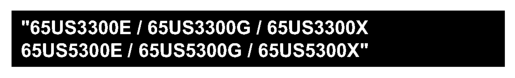

In [21]:
extract_dict_from_image(r"D:\Programming\Projects\Learning python librairies\OCR\cropped_tables\table_1.png", r"D:\Programming\Projects\Learning python librairies\OCR\cropped_tables\table_1.csv")

In [3]:
import cv2
import numpy as np
import pandas as pd
import pytesseract
import os


# ============================================================
# 1. LOAD IMAGE
# ============================================================

def load_table_image(image_path):
    """
    Load a cropped table image.

    Supports:
        - grayscale
        - BGR
        - RGB
        - binary

    Your table is expected to have:
        black background
        white table lines
        white text
    """

    img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

    if img is None:
        raise ValueError(f"Could not read image: {image_path}")

    # -----------------------------------------
    # Handle grayscale
    # -----------------------------------------
    if len(img.shape) == 2:
        gray = img

    # -----------------------------------------
    # Handle BGR / RGB
    # -----------------------------------------
    else:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # -----------------------------------------
    # Make sure image is binary
    #
    # White = foreground
    # Black = background
    # -----------------------------------------

    if np.unique(gray).size > 2:

        _, binary = cv2.threshold(
            gray,
            0,
            255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )

    else:
        binary = gray.copy()

        # Make sure white is foreground
        if np.mean(binary) > 127:
            binary = cv2.bitwise_not(binary)

    return binary


# ============================================================
# 2. REMOVE THE 10 PX PADDING
# ============================================================

def remove_padding(binary, padding=10):

    h, w = binary.shape

    x1 = padding
    y1 = padding

    x2 = w - padding
    y2 = h - padding

    if x2 <= x1 or y2 <= y1:
        return binary

    return binary[y1:y2, x1:x2]


# ============================================================
# 3. DETECT TABLE LINES
# ============================================================

def detect_table_lines(binary):

    h, w = binary.shape

    # --------------------------------------------------------
    # Horizontal lines
    # --------------------------------------------------------

    horizontal_kernel_size = max(20, w // 20)

    horizontal_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (horizontal_kernel_size, 1)
    )

    horizontal_lines = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        horizontal_kernel
    )

    # --------------------------------------------------------
    # Vertical lines
    # --------------------------------------------------------

    vertical_kernel_size = max(20, h // 20)

    vertical_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (1, vertical_kernel_size)
    )

    vertical_lines = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        vertical_kernel
    )

    return horizontal_lines, vertical_lines


# ============================================================
# 4. FIND HORIZONTAL LINE POSITIONS
# ============================================================

def find_horizontal_positions(horizontal_lines):

    # Count white pixels in every row
    row_projection = np.sum(
        horizontal_lines > 0,
        axis=1
    )

    threshold = horizontal_lines.shape[1] * 0.20

    candidate_rows = np.where(
        row_projection >= threshold
    )[0]

    if len(candidate_rows) == 0:
        return []

    # --------------------------------------------------------
    # Group neighboring rows
    # --------------------------------------------------------

    groups = []

    start = candidate_rows[0]
    previous = candidate_rows[0]

    for y in candidate_rows[1:]:

        if y <= previous + 2:
            previous = y

        else:
            groups.append((start, previous))

            start = y
            previous = y

    groups.append((start, previous))

    # --------------------------------------------------------
    # Get center of every line
    # --------------------------------------------------------

    positions = []

    for start, end in groups:

        center = (start + end) // 2

        positions.append(center)

    return positions


# ============================================================
# 5. FIND VERTICAL LINE POSITIONS
# ============================================================

def find_vertical_positions(vertical_lines):

    col_projection = np.sum(
        vertical_lines > 0,
        axis=0
    )

    threshold = vertical_lines.shape[0] * 0.20

    candidate_cols = np.where(
        col_projection >= threshold
    )[0]

    if len(candidate_cols) == 0:
        return []

    # --------------------------------------------------------
    # Group neighboring columns
    # --------------------------------------------------------

    groups = []

    start = candidate_cols[0]
    previous = candidate_cols[0]

    for x in candidate_cols[1:]:

        if x <= previous + 2:
            previous = x

        else:
            groups.append((start, previous))

            start = x
            previous = x

    groups.append((start, previous))

    # --------------------------------------------------------
    # Center
    # --------------------------------------------------------

    positions = []

    for start, end in groups:

        center = (start + end) // 2

        positions.append(center)

    return positions


# ============================================================
# 6. CHECK WHETHER A LINE EXISTS
# ============================================================

def has_vertical_line(
    vertical_lines,
    x,
    y1,
    y2,
    tolerance=3,
    ratio=0.50
):

    x1 = max(0, x - tolerance)
    x2 = min(
        vertical_lines.shape[1],
        x + tolerance + 1
    )

    y1 = max(0, y1)
    y2 = min(
        vertical_lines.shape[0],
        y2
    )

    region = vertical_lines[y1:y2, x1:x2]

    if region.size == 0:
        return False

    white_ratio = np.mean(region > 0)

    return white_ratio >= ratio


# ============================================================
# 7. CHECK WHETHER A HORIZONTAL LINE EXISTS
# ============================================================

def has_horizontal_line(
    horizontal_lines,
    y,
    x1,
    x2,
    tolerance=3,
    ratio=0.50
):

    y1 = max(0, y - tolerance)
    y2 = min(
        horizontal_lines.shape[0],
        y + tolerance + 1
    )

    x1 = max(0, x1)
    x2 = min(
        horizontal_lines.shape[1],
        x2
    )

    region = horizontal_lines[y1:y2, x1:x2]

    if region.size == 0:
        return False

    white_ratio = np.mean(region > 0)

    return white_ratio >= ratio


# ============================================================
# 8. OCR ONE CELL
# ============================================================

def ocr_cell(cell):

    # --------------------------------------------------------
    # Remove borders
    # --------------------------------------------------------

    cell = cell.copy()

    h, w = cell.shape

    border = min(
        5,
        h // 10,
        w // 10
    )

    if border > 0:

        cell = cell[
            border:h-border,
            border:w-border
        ]

    # --------------------------------------------------------
    # Add white padding around text
    # --------------------------------------------------------

    cell = cv2.copyMakeBorder(
        cell,
        8,
        8,
        8,
        8,
        cv2.BORDER_CONSTANT,
        value=0
    )

    # --------------------------------------------------------
    # OCR
    # --------------------------------------------------------

    text = pytesseract.image_to_string(
        cell,
        config="--psm 6"
    )

    # --------------------------------------------------------
    # Clean text
    # --------------------------------------------------------

    text = text.strip()

    text = " ".join(
        text.split()
    )

    return text


# ============================================================
# 9. EXTRACT TABLE
# ============================================================

def extract_table(
    image_path,
    padding=10,
    debug=False
):

    # --------------------------------------------------------
    # Load
    # --------------------------------------------------------

    binary = load_table_image(image_path)

    # --------------------------------------------------------
    # Remove 10 px padding
    # --------------------------------------------------------

    binary = remove_padding(
        binary,
        padding=padding
    )

    # --------------------------------------------------------
    # Detect lines
    # --------------------------------------------------------

    horizontal_lines, vertical_lines = \
        detect_table_lines(binary)

    # --------------------------------------------------------
    # Find line coordinates
    # --------------------------------------------------------

    horizontal_positions = \
        find_horizontal_positions(
            horizontal_lines
        )

    vertical_positions = \
        find_vertical_positions(
            vertical_lines
        )

    print(
        "Horizontal lines:",
        horizontal_positions
    )

    print(
        "Vertical lines:",
        vertical_positions
    )

    if len(horizontal_positions) < 2:
        raise ValueError(
            "Could not detect horizontal table lines."
        )

    if len(vertical_positions) < 2:
        raise ValueError(
            "Could not detect vertical table lines."
        )

    # --------------------------------------------------------
    # Number of possible rows/columns
    # --------------------------------------------------------

    rows = len(horizontal_positions) - 1
    cols = len(vertical_positions) - 1

    # --------------------------------------------------------
    # Matrix telling which elementary grid cells are occupied
    # --------------------------------------------------------

    used = np.zeros(
        (rows, cols),
        dtype=bool
    )

    logical_cells = []

    # ========================================================
    # MERGED CELL DETECTION
    # ========================================================

    for r in range(rows):

        c = 0

        while c < cols:

            if used[r, c]:
                c += 1
                continue

            # ------------------------------------------------
            # Find how far right the cell extends
            # ------------------------------------------------

            end_col = c

            while end_col + 1 < cols:

                boundary_x = vertical_positions[
                    end_col + 1
                ]

                y1 = horizontal_positions[r]
                y2 = horizontal_positions[r + 1]

                exists = has_vertical_line(
                    vertical_lines,
                    boundary_x,
                    y1,
                    y2
                )

                if exists:
                    break

                end_col += 1

            # ------------------------------------------------
            # Find how far down the cell extends
            # ------------------------------------------------

            end_row = r

            while end_row + 1 < rows:

                boundary_y = horizontal_positions[
                    end_row + 1
                ]

                x1 = vertical_positions[c]
                x2 = vertical_positions[end_col + 1]

                exists = has_horizontal_line(
                    horizontal_lines,
                    boundary_y,
                    x1,
                    x2
                )

                if exists:
                    break

                end_row += 1

            # ------------------------------------------------
            # Mark elementary cells as used
            # ------------------------------------------------

            for rr in range(
                r,
                end_row + 1
            ):

                for cc in range(
                    c,
                    end_col + 1
                ):

                    used[rr, cc] = True

            # ------------------------------------------------
            # Store logical cell
            # ------------------------------------------------

            logical_cells.append({
                "row": r,
                "col": c,
                "rowspan": end_row - r + 1,
                "colspan": end_col - c + 1,
                "x1": vertical_positions[c],
                "y1": horizontal_positions[r],
                "x2": vertical_positions[end_col + 1],
                "y2": horizontal_positions[end_row + 1]
            })

            c = end_col + 1

    # ========================================================
    # CREATE DATAFRAME
    # ========================================================

    data = [
        [""] * cols
        for _ in range(rows)
    ]

    # --------------------------------------------------------
    # OCR every logical cell
    # --------------------------------------------------------

    for cell in logical_cells:

        x1 = cell["x1"]
        y1 = cell["y1"]

        x2 = cell["x2"]
        y2 = cell["y2"]

        # Small inset to remove table borders
        inset = 3

        x1_crop = x1 + inset
        y1_crop = y1 + inset

        x2_crop = x2 - inset
        y2_crop = y2 - inset

        cell_image = binary[
            y1_crop:y2_crop,
            x1_crop:x2_crop
        ]

        text = ocr_cell(
            cell_image
        )

        # ----------------------------------------------------
        # Put text into first position of merged cell
        # ----------------------------------------------------

        data[
            cell["row"]
        ][
            cell["col"]
        ] = text

    df = pd.DataFrame(data)

    return df, logical_cells, binary


# ============================================================
# 10. PROCESS ONE IMAGE
# ============================================================

def process_table(
    image_path,
    output_csv
):

    print("=" * 60)
    print(
        f"Processing: {image_path}"
    )
    print("=" * 60)

    df, cells, binary = extract_table(
        image_path,
        padding=10
    )

    # --------------------------------------------------------
    # Save CSV
    # --------------------------------------------------------

    df.to_csv(
        output_csv,
        index=False,
        header=False,
        encoding="utf-8-sig"
    )

    print("\nExtracted table:")
    print(df)

    print(
        f"\nSaved to: {output_csv}"
    )

    return df


# ============================================================
# 11. PROCESS WHOLE FOLDER
# ============================================================

def process_folder(
    input_folder,
    output_folder
):

    os.makedirs(
        output_folder,
        exist_ok=True
    )

    extensions = (
        ".png",
        ".jpg",
        ".jpeg",
        ".bmp",
        ".tif",
        ".tiff"
    )

    for filename in os.listdir(
        input_folder
    ):

        if not filename.lower().endswith(
            extensions
        ):
            continue

        input_path = os.path.join(
            input_folder,
            filename
        )

        base_name = os.path.splitext(
            filename
        )[0]

        output_path = os.path.join(
            output_folder,
            base_name + ".csv"
        )

        try:

            process_table(
                input_path,
                output_path
            )

        except Exception as e:

            print(
                f"ERROR processing {filename}:"
            )

            print(e)


# ============================================================
# 12. RUN
# ============================================================
input_folder = "cropped_tables"
output_folder = "CSV_Tables"
process_folder(
  input_folder,
  output_folder
  
)
# load_table_image(r"D:\Programming\Projects\Learning python librairies\OCR\cropped_tables\table_1.png")

Processing: cropped_tables\table_1.png
Horizontal lines: [7, 157, 248, 339, 430, 520, 637, 728, 964, 1054, 1145]
Vertical lines: [7, 873, 1285]

Extracted table:
                                                   0  \
0  "65US3300E / 65US3300G / 65US3300X 65US5300E /...   
1                     Carton Dimensions (L*W*H) (mm)   
2                         Net Weight With Stand (Kg)   
3                   Gross Weight With Packaging (Kg)   
4                                   Power Supply (V)   
5                      Power Consumption (TV On) (W)   
6                    Power Consumption (Standby) (W)   
7                                          TV System   
8                             Sound Output Power (W)   
9                                         Resolution   

                                                1  
0                                                  
1                                    1577*166*978  
2                                            18.2  
3            

In [4]:
import cv2
import numpy as np

path = r"D:\Programming\Projects\Learning python librairies\OCR\cropped_tables\table_1.png"

img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

print("Image loaded:", img is not None)
print("Shape:", img.shape)
print("Dtype:", img.dtype)
print("Unique values:", np.unique(img))

print("\nBlack pixels:", np.sum(img == 0))
print("White pixels:", np.sum(img == 255))

Image loaded: True
Shape: (1173, 1313)
Dtype: uint8
Unique values: [  0 255]

Black pixels: 1297687
White pixels: 242462


In [5]:
from img2table.document import Image

path = r"D:\Programming\Projects\Learning python librairies\OCR\cropped_tables\table_1.png"

image = Image(src=path)

tables = image.extract_tables(
    ocr=None,
    implicit_rows=False,
    implicit_columns=False
)

print("Tables detected:", len(tables))

Tables detected: 1


In [7]:
from img2table.document import Image
from img2table.ocr import TesseractOCR

# --------------------------------------------------
# Paths
# --------------------------------------------------

image_path = (
    r"D:\Programming\Projects\Learning python librairies"
    r"\OCR\cropped_tables\table_1.png"
)

tessdata_path = (
    r"E:\New program files\Tesseract\tessdata"
)

# --------------------------------------------------
# Create img2table image
# --------------------------------------------------

image = Image(
    src=image_path
)

# --------------------------------------------------
# Create Tesseract OCR
# --------------------------------------------------

ocr = TesseractOCR(
    lang="eng",
    tessdata_dir=tessdata_path
)

# --------------------------------------------------
# Extract table + OCR
# --------------------------------------------------

tables = image.extract_tables(
    ocr=ocr,
    implicit_rows=False,
    implicit_columns=False
)

# --------------------------------------------------
# Check result
# --------------------------------------------------

print("Tables detected:", len(tables))

if len(tables) == 0:

    print("No table was detected.")

else:

    print("\n========== TABLE DATA ==========\n")

    df = tables[0].df

    print(df)

    print("\n========== DATAFRAME INFO ==========\n")

    print("Rows:", len(df))
    print("Columns:", len(df.columns))

Tables detected: 0
No table was detected.


In [8]:
from img2table.document import Image

image_path = r"D:\Programming\Projects\Learning python librairies\OCR\cropped_tables\table_1.png"

image = Image(src=image_path)

tables = image.extract_tables(
    ocr=None,
    implicit_rows=False,
    implicit_columns=False
)

print("Tables detected:", len(tables))

if tables:
    table = tables[0]

    print("\nTABLE OBJECT:")
    print(table)

    print("\nDATAFRAME:")
    print(table.df)

    print("\nBBOX:")
    print(table.bbox)

Tables detected: 1

TABLE OBJECT:
ExtractedTable(title=None, bbox=(15, 15, 1296, 1156),shape=(10, 2))

DATAFRAME:
      0     1
0  None  None
1  None  None
2  None  None
3  None  None
4  None  None
5  None  None
6  None  None
7  None  None
8  None  None
9  None  None

BBOX:
BBox(x1=15, y1=15, x2=1296, y2=1156)


In [5]:
import os
import subprocess
import pytesseract

# ============================================================
# YOUR TESSERACT INSTALLATION
# ============================================================

TESSERACT_EXE = r"E:\New program files\Tesseract\tesseract.exe"
TESSDATA_DIR = r"E:\New program files\Tesseract\tessdata"

# ============================================================
# CHECK FILES
# ============================================================

print("1. Tesseract executable exists:")
print(os.path.isfile(TESSERACT_EXE))

print("\n2. Tessdata directory exists:")
print(os.path.isdir(TESSDATA_DIR))

print("\n3. eng.traineddata exists:")
print(
    os.path.isfile(
        os.path.join(
            TESSDATA_DIR,
            "eng.traineddata"
        )
    )
)

# ============================================================
# TEST TESSERACT DIRECTLY
# ============================================================

print("\n4. Tesseract version:")

result = subprocess.run(
    [
        TESSERACT_EXE,
        "--version"
    ],
    capture_output=True,
    text=True
)

print(result.stdout)

# ============================================================
# TEST LANGUAGES
# ============================================================

print("\n5. Tesseract languages:")

result = subprocess.run(
    [
        TESSERACT_EXE,
        "--list-langs",
        "--tessdata-dir",
        TESSDATA_DIR
    ],
    capture_output=True,
    text=True
)

print(result.stdout)

print("stderr:")
print(result.stderr)

1. Tesseract executable exists:
True

2. Tessdata directory exists:
True

3. eng.traineddata exists:
True

4. Tesseract version:
tesseract v5.5.3.20260724
 leptonica-1.87.0
  libgif 5.2.2 : libjpeg 8d (libjpeg-turbo 3.1.3) : libpng 1.6.58 : libtiff 4.7.2 : zlib 1.3.1 : libwebp 1.6.0 : libopenjp2 2.5.4
 Found AVX2
 Found AVX
 Found FMA
 Found SSE4.1
 Found libarchive 3.8.8 zlib/1.3.2 liblzma/5.8.3 bz2lib/1.0.8 liblz4/1.10.0 libzstd/1.5.7 expat/expat_2.8.2 cng/1.0 libb2/system
 Found libcurl/8.21.0 Schannel zlib/1.3.2 brotli/1.2.0 zstd/1.5.7 libidn2/2.3.8 libpsl/0.21.5 libssh2/1.11.1 WinLDAP


5. Tesseract languages:
List of available languages in "E:\New program files\Tesseract\tessdata/" (161):
afr
amh
ara
asm
aze
aze_cyrl
bel
ben
bod
bos
bre
bul
cat
ceb
ces
chi_sim
chi_sim_vert
chi_tra
chi_tra_vert
chr
cos
cym
dan
deu
deu_latf
div
dzo
ell
eng
enm
epo
equ
est
eus
fao
fas
fil
fin
fra
frm
fry
gla
gle
glg
grc
guj
hat
heb
hin
hrv
hun
hye
iku
ind
isl
ita
ita_old
jav
jpn
jpn_vert
kan
kat
kat

In [6]:
import img2table
import inspect

from img2table.ocr import TesseractOCR

print("img2table version:")
print(img2table.__version__)

print("\nimg2table location:")
print(img2table.__file__)

print("\nTesseractOCR source:")
print(inspect.getsource(TesseractOCR.__init__))

img2table version:


AttributeError: module 'img2table' has no attribute '__version__'

In [7]:
import importlib.metadata
import img2table
import inspect

from img2table.ocr import TesseractOCR

print("img2table version:")
print(importlib.metadata.version("img2table"))

print("\nimg2table location:")
print(img2table.__file__)

print("\nTesseractOCR source:")
print(inspect.getsource(TesseractOCR.__init__))

img2table version:
2.0.0

img2table location:
c:\Users\elkha\anaconda3\Lib\site-packages\img2table\__init__.py

TesseractOCR source:
    def __init__(
        self,
        n_threads: int = 1,
        lang: str = "eng",
        psm: int = 11,
        tessdata_dir: str | None = None,
    ) -> None:
        """
        Initialization of Tesseract OCR instance
        :param n_threads: number of concurrent threads used for Tesseract
        :param lang: lang parameter used in Tesseract
        :param psm: PSM parameter used in Tesseract
        :param tessdata_dir: directory containing Tesseract traineddata files
        """
        if isinstance(n_threads, int):
            self.n_threads = n_threads
        else:
            raise TypeError(f"Invalid type {type(n_threads)} for n_threads argument")

        if isinstance(lang, str):
            self.lang = lang
        else:
            raise TypeError(f"Invalid type {type(lang)} for lang argument")

        if isinstance(psm, int):
    

In [8]:
import os
import shutil

TESSERACT_DIR = r"E:\New program files\Tesseract"

# Add Tesseract to PATH
os.environ["PATH"] = (
    TESSERACT_DIR
    + os.pathsep
    + os.environ["PATH"]
)

# Tell Tesseract where tessdata is
os.environ["TESSDATA_PREFIX"] = (
    TESSERACT_DIR + r"\tessdata"
)

print("Tesseract found at:")
print(shutil.which("tesseract"))

print("\nTESSDATA_PREFIX:")
print(os.environ["TESSDATA_PREFIX"])

Tesseract found at:
.\tesseract.PY

TESSDATA_PREFIX:
E:\New program files\Tesseract\tessdata


In [52]:
import cv2
import numpy as np
import pytesseract
import csv
import os


# ============================================================
# CHECK IF FOUR CONTOURS FORM A RECTANGLE
# ============================================================

def is_rectangle_or_not(
    contours,
    tolerance=10
):
    """
    Check whether 4 contours form the four sides
    of one rectangle.

    contours:
        [top, bottom, left, right]

    Returns:
        True / False
    """

    if len(contours) != 4:
        return False

    boxes = []

    for contour in contours:

        x, y, w, h = cv2.boundingRect(
            contour
        )

        boxes.append(
            {
                "x": x,
                "y": y,
                "w": w,
                "h": h,
                "x2": x + w,
                "y2": y + h
            }
        )

    # ========================================================
    # Separate horizontal and vertical contours
    # ========================================================

    horizontal = []
    vertical = []

    for box in boxes:

        if box["w"] > box["h"]:
            horizontal.append(box)

        elif box["h"] > box["w"]:
            vertical.append(box)

    # A rectangle needs:
    #
    # 2 horizontal
    # 2 vertical

    if len(horizontal) != 2:
        return False

    if len(vertical) != 2:
        return False

    # ========================================================
    # Top / Bottom
    # ========================================================

    horizontal.sort(
        key=lambda b: b["y"]
    )

    top = horizontal[0]
    bottom = horizontal[1]

    # ========================================================
    # Left / Right
    # ========================================================

    vertical.sort(
        key=lambda b: b["x"]
    )

    left = vertical[0]
    right = vertical[1]

    # ========================================================
    # Check that top is above bottom
    # ========================================================

    if top["y"] >= bottom["y"]:
        return False

    # ========================================================
    # Check that left is before right
    # ========================================================

    if left["x"] >= right["x"]:
        return False

    # ========================================================
    # Horizontal lines must cover vertical lines
    # ========================================================

    if top["x"] > left["x"] + tolerance:
        return False

    if top["x2"] < right["x2"] - tolerance:
        return False

    if bottom["x"] > left["x"] + tolerance:
        return False

    if bottom["x2"] < right["x2"] - tolerance:
        return False

    # ========================================================
    # Vertical lines must cover horizontal lines
    # ========================================================

    if left["y"] > top["y"] + tolerance:
        return False

    if left["y2"] < bottom["y2"] - tolerance:
        return False

    if right["y"] > top["y"] + tolerance:
        return False

    if right["y2"] < bottom["y2"] - tolerance:
        return False

    # ========================================================
    # Check opposite sides approximately align
    # ========================================================

    if abs(
        top["x"] - bottom["x"]
    ) > tolerance:

        return False

    if abs(
        top["x2"] - bottom["x2"]
    ) > tolerance:

        return False

    if abs(
        left["y"] - right["y"]
    ) > tolerance:

        return False

    if abs(
        left["y2"] - right["y2"]
    ) > tolerance:

        return False

    return True


# ============================================================
# GET RECTANGLE COORDINATES FROM FOUR CONTOURS
# ============================================================

def get_rectangle_from_contours(
    contours
):

    boxes = []

    for contour in contours:

        x, y, w, h = cv2.boundingRect(
            contour
        )

        boxes.append(
            {
                "x": x,
                "y": y,
                "w": w,
                "h": h,
                "x2": x + w,
                "y2": y + h
            }
        )

    horizontal = [
        box for box in boxes
        if box["w"] > box["h"]
    ]

    vertical = [
        box for box in boxes
        if box["h"] > box["w"]
    ]

    horizontal.sort(
        key=lambda b: b["y"]
    )

    vertical.sort(
        key=lambda b: b["x"]
    )

    top = horizontal[0]
    bottom = horizontal[1]

    left = vertical[0]
    right = vertical[1]

    return {
        "x1": int(
            round(
                (
                    left["x"]
                    +
                    left["x2"]
                ) / 2
            )
        ),

        "y1": int(
            round(
                (
                    top["y"]
                    +
                    top["y2"]
                ) / 2
            )
        ),

        "x2": int(
            round(
                (
                    right["x"]
                    +
                    right["x2"]
                ) / 2
            )
        ),

        "y2": int(
            round(
                (
                    bottom["y"]
                    +
                    bottom["y2"]
                ) / 2
            )
        )
    }


# ============================================================
# FIND RECTANGLES USING FOUR CONTOURS
# ============================================================

def find_rectangles_from_contours(
    contours
):

    print(
        f"Checking {len(contours)} contours..."
    )

    rectangles = []

    number_of_contours = len(
        contours
    )

    # ========================================================
    # Try every combination of 4 contours
    # ========================================================

    for i in range(
        number_of_contours
    ):

        for j in range(
            i + 1,
            number_of_contours
        ):

            for k in range(
                j + 1,
                number_of_contours
            ):

                for l in range(
                    k + 1,
                    number_of_contours
                ):

                    candidate = [
                        contours[i],
                        contours[j],
                        contours[k],
                        contours[l]
                    ]

                    # ------------------------------------------------
                    # Use your rectangle function
                    # ------------------------------------------------

                    if is_rectangle_or_not(
                        candidate
                    ):

                        rectangle = (
                            get_rectangle_from_contours(
                                candidate
                            )
                        )

                        rectangles.append(
                            rectangle
                        )

    # ========================================================
    # Remove duplicate rectangles
    # ========================================================

    unique_rectangles = []

    for rectangle in rectangles:

        duplicate = False

        for existing in unique_rectangles:

            if (
                abs(
                    rectangle["x1"]
                    -
                    existing["x1"]
                ) <= 5
                and
                abs(
                    rectangle["y1"]
                    -
                    existing["y1"]
                ) <= 5
                and
                abs(
                    rectangle["x2"]
                    -
                    existing["x2"]
                ) <= 5
                and
                abs(
                    rectangle["y2"]
                    -
                    existing["y2"]
                ) <= 5
            ):

                duplicate = True

                break

        if not duplicate:

            unique_rectangles.append(
                rectangle
            )

    # ========================================================
    # Sort by Y then X
    # ========================================================

    unique_rectangles.sort(
        key=lambda r: (
            r["y1"],
            r["x1"]
        )
    )

    print(
        f"Rectangles detected: "
        f"{len(unique_rectangles)}"
    )

    return unique_rectangles


# ============================================================
# GET GRID POSITIONS
# ============================================================

def get_grid_positions(
    rectangles,
    tolerance=10
):

    x_positions = []
    y_positions = []

    for rectangle in rectangles:

        x_positions.append(
            rectangle["x1"]
        )

        x_positions.append(
            rectangle["x2"]
        )

        y_positions.append(
            rectangle["y1"]
        )

        y_positions.append(
            rectangle["y2"]
        )

    # ========================================================
    # Merge nearby coordinates
    # ========================================================

    def merge_positions(
        positions
    ):

        if not positions:
            return []

        positions = sorted(
            positions
        )

        result = [
            positions[0]
        ]

        for position in positions[1:]:

            if (
                position
                -
                result[-1]
            ) <= tolerance:

                result[-1] = int(
                    (
                        result[-1]
                        +
                        position
                    ) / 2
                )

            else:

                result.append(
                    position
                )

        return result

    return (
        merge_positions(x_positions),
        merge_positions(y_positions)
    )


# ============================================================
# FIND CLOSEST GRID POSITION
# ============================================================

def get_position(
    value,
    positions,
    tolerance=10
):

    for i, position in enumerate(
        positions
    ):

        if abs(
            value - position
        ) <= tolerance:

            return i

    return None


# ============================================================
# ASSIGN RECTANGLES TO ROW/COLUMN
# ============================================================

def assign_positions(
    rectangles,
    x_positions,
    y_positions
):

    cells = []

    for rectangle in rectangles:

        row = get_position(
            rectangle["y1"],
            y_positions
        )

        col = get_position(
            rectangle["x1"],
            x_positions
        )

        row_end = get_position(
            rectangle["y2"],
            y_positions
        )

        col_end = get_position(
            rectangle["x2"],
            x_positions
        )

        if (
            row is None
            or col is None
            or row_end is None
            or col_end is None
        ):
            continue

        cells.append(
            {
                "x1": rectangle["x1"],
                "y1": rectangle["y1"],
                "x2": rectangle["x2"],
                "y2": rectangle["y2"],

                "row": row,
                "col": col,

                "row_end": row_end,
                "col_end": col_end,

                "row_span":
                    row_end - row,

                "col_span":
                    col_end - col
            }
        )

    cells.sort(
        key=lambda c: (
            c["row"],
            c["col"]
        )
    )

    return cells


# ============================================================
# OCR CELL
# ============================================================

def extract_text_from_cell(
    img,
    cell
):

    x1 = cell["x1"]
    y1 = cell["y1"]
    x2 = cell["x2"]
    y2 = cell["y2"]

    # --------------------------------------------------------
    # DIRECT CROP
    #
    # No threshold
    # No blur
    # No morphology
    # No inversion
    # --------------------------------------------------------

    crop = img[
        y1:y2,
        x1:x2
    ]

    if crop.size == 0:

        return "", crop

    text = pytesseract.image_to_string(
        crop,
        config="--oem 3 --psm 6"
    )

    text = text.replace(
        "\n",
        " "
    )

    text = text.replace(
        "\r",
        " "
    )

    text = " ".join(
        text.split()
    )

    return text.strip(), crop


# ============================================================
# CREATE CSV
# ============================================================

def create_csv(
    img,
    cells,
    rows,
    cols,
    output_csv
):

    print(
        "Creating CSV grid..."
    )

    # --------------------------------------------------------
    # Create fixed grid
    # --------------------------------------------------------

    table = [
        ["" for _ in range(cols)]
        for _ in range(rows)
    ]

    for index, cell in enumerate(
        cells,
        start=1
    ):

        print(
            f"OCR cell "
            f"{index}/{len(cells)} "
            f"-> row={cell['row']}, "
            f"col={cell['col']}"
        )

        text, crop = (
            extract_text_from_cell(
                img,
                cell
            )
        )

        # ----------------------------------------------------
        # Put text at ORIGINAL position
        # ----------------------------------------------------

        table[
            cell["row"]
        ][
            cell["col"]
        ] = text

        print(
            f"    Text: {repr(text)}"
        )

    # --------------------------------------------------------
    # Write CSV
    # --------------------------------------------------------

    with open(
        output_csv,
        "w",
        newline="",
        encoding="utf-8-sig"
    ) as file:

        writer = csv.writer(
            file
        )

        writer.writerows(
            table
        )

    print(
        f"CSV saved: {output_csv}"
    )

    return table


# ============================================================
# MAIN FUNCTION
# ============================================================

def extract_csv_from_image(
    input_path_image,
    output_path_csv
):
    """
    Input MUST be binary:

        background = black
        text/lines = white
    """

    print()
    print("=" * 70)

    print(
        f"Processing: "
        f"{os.path.basename(input_path_image)}"
    )

    print("=" * 70)

    # ========================================================
    # 1. Read binary image
    # ========================================================

    print(
        "1. Reading binary image..."
    )

    img = cv2.imread(
        input_path_image,
        cv2.IMREAD_GRAYSCALE
    )

    if img is None:

        raise FileNotFoundError(
            input_path_image
        )

    print(
        f"   Size: "
        f"{img.shape[1]} x "
        f"{img.shape[0]}"
    )

    # ========================================================
    # 2. Horizontal kernel
    # ========================================================

    print(
        "2. Detecting horizontal lines..."
    )

    horizontal_kernel_size = max(
        30,
        img.shape[1] // 30
    )

    horizontal_kernel = (
        cv2.getStructuringElement(
            cv2.MORPH_RECT,
            (
                horizontal_kernel_size,
                1
            )
        )
    )

    horizontal_lines = (
        cv2.morphologyEx(
            img,
            cv2.MORPH_OPEN,
            horizontal_kernel
        )
    )

    # ========================================================
    # 3. Vertical kernel
    # ========================================================

    print(
        "3. Detecting vertical lines..."
    )

    vertical_kernel_size = max(
        30,
        img.shape[0] // 30
    )

    vertical_kernel = (
        cv2.getStructuringElement(
            cv2.MORPH_RECT,
            (
                1,
                vertical_kernel_size
            )
        )
    )

    vertical_lines = (
        cv2.morphologyEx(
            img,
            cv2.MORPH_OPEN,
            vertical_kernel
        )
    )

    # ========================================================
    # 4. Combine
    # ========================================================

    print(
        "4. Combining table lines..."
    )

    # --------------------------------------------------------
    # NOTE:
    #
    # AND keeps only intersections.
    #
    # OR keeps the complete horizontal + vertical structure.
    #
    # Since we need to determine the four sides of a rectangle,
    # OR is normally required here.
    # --------------------------------------------------------

    table_lines = cv2.bitwise_or(
        vertical_lines,
        horizontal_lines
    )

    # If you KNOW that your AND version is producing the
    # contours you need, replace the previous line with:
    #
    # table_lines = cv2.bitwise_and(
    #     vertical_lines,
    #     horizontal_lines
    # )

    # ========================================================
    # 5. Find contours
    # ========================================================

    print(
        "5. Finding contours..."
    )

    contours, _ = cv2.findContours(
        table_lines,
        cv2.RETR_LIST,
        cv2.CHAIN_APPROX_SIMPLE
    )

    print(
        f"   Contours found: "
        f"{len(contours)}"
    )

    # ========================================================
    # 6. Rectangle detection
    # ========================================================

    print(
        "6. Checking combinations of "
        "four contours..."
    )

    rectangles = (
        find_rectangles_from_contours(
            contours
        )
    )

    if not rectangles:

        raise RuntimeError(
            "No rectangles were detected."
        )

    # ========================================================
    # 7. Grid positions
    # ========================================================

    print(
        "7. Building table grid..."
    )

    x_positions, y_positions = (
        get_grid_positions(
            rectangles
        )
    )

    rows = len(
        y_positions
    ) - 1

    cols = len(
        x_positions
    ) - 1

    print(
        f"   Grid: "
        f"{rows} rows x "
        f"{cols} columns"
    )

    # ========================================================
    # 8. Assign cells
    # ========================================================

    print(
        "8. Assigning cell positions..."
    )

    cells = assign_positions(
        rectangles,
        x_positions,
        y_positions
    )

    # ========================================================
    # 9. Merged cells
    # ========================================================

    print(
        "9. Checking merged cells..."
    )

    for cell in cells:

        if (
            cell["row_span"] > 1
            or
            cell["col_span"] > 1
        ):

            print(
                "   MERGED CELL:"
                f" row={cell['row']}"
                f" col={cell['col']}"
                f" span="
                f"{cell['row_span']}x"
                f"{cell['col_span']}"
            )

    # ========================================================
    # 10. OCR + CSV
    # ========================================================

    print(
        "10. Extracting text..."
    )

    table = create_csv(
        img,
        cells,
        rows,
        cols,
        output_path_csv
    )

    # ========================================================
    # 11. Display result
    # ========================================================

    print()
    print("=" * 70)
    print("FINAL TABLE")
    print("=" * 70)

    for row in table:

        print(
            row
        )

    print("=" * 70)

    return table


# ============================================================
# TEST ALL CROPPED TABLES
# ============================================================

def test_all_tables():

    input_folder = (
        r"D:\Programming\Projects\Learning python librairies"
        r"\OCR\cropped_tables"
    )

    output_folder = os.path.join(
        input_folder,
        "csv_output"
    )

    os.makedirs(
        output_folder,
        exist_ok=True
    )

    extensions = (
        ".png",
        ".jpg",
        ".jpeg",
        ".bmp",
        ".tif",
        ".tiff"
    )

    images = [
        os.path.join(
            input_folder,
            filename
        )
        for filename in os.listdir(
            input_folder
        )
        if filename.lower().endswith(
            extensions
        )
    ]

    images.sort()

    print(
        f"Found {len(images)} table images."
    )

    successful = 0
    failed = 0

    for index, image_path in enumerate(
        images,
        start=1
    ):

        filename = os.path.basename(
            image_path
        )

        name = os.path.splitext(
            filename
        )[0]

        output_csv = os.path.join(
            output_folder,
            f"{name}.csv"
        )

        print()
        print(
            f"TABLE {index}/{len(images)}"
        )

        try:

            extract_csv_from_image(
                image_path,
                output_csv
            )

            successful += 1

        except Exception as error:

            failed += 1

            print(
                f"ERROR in {filename}:"
            )

            print(
                error
            )

    print()
    print("=" * 70)
    print("TEST FINISHED")
    print("=" * 70)

    print(
        f"Total     : {len(images)}"
    )

    print(
        f"Successful: {successful}"
    )

    print(
        f"Failed    : {failed}"
    )

    print(
        f"CSV folder:\n{output_folder}"
    )

    print("=" * 70)


# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":

    test_all_tables()

Found 5 table images.

TABLE 1/5

Processing: table_1.png
1. Reading binary image...
   Size: 1313 x 1173
2. Detecting horizontal lines...
3. Detecting vertical lines...
4. Combining table lines...
5. Finding contours...
   Contours found: 40
6. Checking combinations of four contours...
Checking 40 contours...
Rectangles detected: 0
ERROR in table_1.png:
No rectangles were detected.

TABLE 2/5

Processing: table_2.png
1. Reading binary image...
   Size: 1313 x 1148
2. Detecting horizontal lines...
3. Detecting vertical lines...
4. Combining table lines...
5. Finding contours...
   Contours found: 40
6. Checking combinations of four contours...
Checking 40 contours...
Rectangles detected: 0
ERROR in table_2.png:
No rectangles were detected.

TABLE 3/5

Processing: table_3.png
1. Reading binary image...
   Size: 1313 x 1154
2. Detecting horizontal lines...
3. Detecting vertical lines...
4. Combining table lines...
5. Finding contours...
   Contours found: 40
6. Checking combinations of f

(array([[[1694, 2229]],

       [[1694, 2242]],

       [[1707, 2242]],

       [[1707, 2229]]], dtype=int32), array([[[1694, 2047]],

       [[1694, 2060]],

       [[1707, 2060]],

       [[1707, 2047]]], dtype=int32), array([[[1694, 1863]],

       [[1694, 1875]],

       [[1707, 1875]],

       [[1707, 1863]]], dtype=int32), array([[[1694, 1391]],

       [[1694, 1404]],

       [[1707, 1404]],

       [[1707, 1391]]], dtype=int32), array([[[1694, 1207]],

       [[1694, 1220]],

       [[1707, 1220]],

       [[1707, 1207]]], dtype=int32), array([[[1694, 1025]],

       [[1694, 1038]],

       [[1707, 1038]],

       [[1707, 1025]]], dtype=int32), array([[[1694,  844]],

       [[1694,  856]],

       [[1707,  856]],

       [[1707,  844]]], dtype=int32), array([[[1694,  654]],

       [[1694,  667]],

       [[1707,  667]],

       [[1707,  654]]], dtype=int32), array([[[1694,  472]],

       [[1694,  485]],

       [[1707,  485]],

       [[1707,  472]]], dtype=int32), array([[[

-1

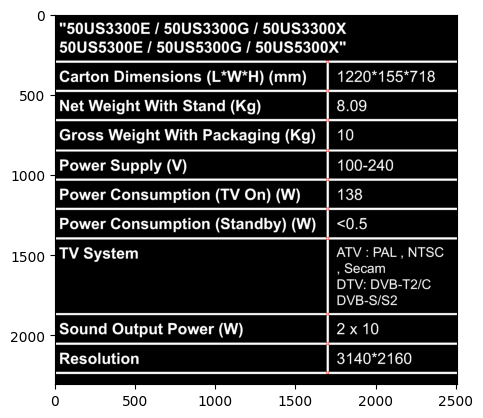

In [42]:
import cv2
import matplotlib.pyplot as plt
input_path_image = r"D:\Programming\Projects\Learning python librairies\OCR\binary_table.png"
img = cv2.imread(input_path_image, cv2.IMREAD_GRAYSCALE)
_, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
horizontal_kernel_size = max(30, img.shape[0] // 30)
horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (horizontal_kernel_size, 1))
vertical_kernel_size = max(30, img.shape[1] // 30)
vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1,vertical_kernel_size))

horizontal_lines = cv2.morphologyEx(img, cv2.MORPH_OPEN, horizontal_kernel)
vertical_lines = cv2.morphologyEx(img, cv2.MORPH_OPEN, vertical_kernel)
table_structure = cv2.add(
    vertical_lines,
    horizontal_lines
)
table_lines = cv2.bitwise_and(vertical_lines, horizontal_lines)
# print (get_line_positions(horizontal_lines, vertical_lines))
contour, hierarchy = cv2.findContours(table_lines, cv2.RETR_LIST,cv2.CHAIN_APPROX_SIMPLE)
# import matplotlib.pyplot as plt
plt.imshow(cv2.drawContours(cv2.cvtColor(img, cv2.COLOR_GRAY2BGR), contour, -1, (255, 0, 0), 2))
# cv2.imshow("Table Contours", cv2.drawContours(cv2.cvtColor(img, cv2.COLOR_GRAY2BGR), contour, -1, (255, 255, 255), 2))
print (contour)
cv2.waitKey(0)

In [ ]:
import cv2
import numpy as np


def is_rectangle_from_four_contours(
    contours,
    tolerance=5,
    min_width=20,
    min_height=20
):
    """
    Check whether 4 contours form one rectangle.

    contours must contain exactly 4 contours.

    Returns:
        True  -> contours form a rectangle
        False -> they do not
    """

    if len(contours) != 4:
        return False

    boxes = []

    for contour in contours:

        x, y, w, h = cv2.boundingRect(contour)

        boxes.append(
            {
                "x1": x,
                "y1": y,
                "x2": x + w,
                "y2": y + h,
                "w": w,
                "h": h
            }
        )

    # --------------------------------------------------------
    # Separate horizontal and vertical contours
    # --------------------------------------------------------

    horizontal = []
    vertical = []

    for box in boxes:

        if box["w"] >= box["h"]:
            horizontal.append(box)

        else:
            vertical.append(box)

    # A rectangle should have:
    # 2 horizontal sides
    # 2 vertical sides

    if len(horizontal) != 2:
        return False

    if len(vertical) != 2:
        return False

    # --------------------------------------------------------
    # Check horizontal sides
    # --------------------------------------------------------

    top = min(
        horizontal,
        key=lambda b: b["y1"]
    )

    bottom = max(
        horizontal,
        key=lambda b: b["y1"]
    )

    # Horizontal sides should have approximately
    # the same X range.

    if abs(
        top["x1"] - bottom["x1"]
    ) > tolerance:

        return False

    if abs(
        top["x2"] - bottom["x2"]
    ) > tolerance:

        return False

    # They must actually be separated vertically.

    if bottom["y1"] <= top["y1"]:
        return False

    # --------------------------------------------------------
    # Check vertical sides
    # --------------------------------------------------------

    left = min(
        vertical,
        key=lambda b: b["x1"]
    )

    right = max(
        vertical,
        key=lambda b: b["x1"]
    )

    # Vertical sides should have approximately
    # the same Y range.

    if abs(
        left["y1"] - right["y1"]
    ) > tolerance:

        return False

    if abs(
        left["y2"] - right["y2"]
    ) > tolerance:

        return False

    # They must actually be separated horizontally.

    if right["x1"] <= left["x1"]:
        return False

    # --------------------------------------------------------
    # Check width and height
    # --------------------------------------------------------

    width = (
        right["x1"] -
        left["x1"]
    )

    height = (
        bottom["y1"] -
        top["y1"]
    )

    if width < min_width:
        return False

    if height < min_height:
        return False

    # --------------------------------------------------------
    # Check that horizontal sides span the vertical sides
    # --------------------------------------------------------

    if (
        top["x1"] > left["x1"] + tolerance
        or
        top["x2"] < right["x2"] - tolerance
    ):
        return False

    if (
        bottom["x1"] > left["x1"] + tolerance
        or
        bottom["x2"] < right["x2"] - tolerance
    ):
        return False

    # --------------------------------------------------------
    # Check that vertical sides span the horizontal sides
    # --------------------------------------------------------

    if (
        left["y1"] > top["y1"] + tolerance
        or
        left["y2"] < bottom["y2"] - tolerance
    ):
        return False

    if (
        right["y1"] > top["y1"] + tolerance
        or
        right["y2"] < bottom["y2"] - tolerance
    ):
        return False

    return True

In [49]:
import cv2
import numpy as np
import pytesseract
import csv
import os
import time


# ============================================================
# Runtime logger
# ============================================================

def log(message):
    print(
        f"[{time.strftime('%H:%M:%S')}] {message}",
        flush=True
    )


# ============================================================
# Check that image is binary
# ============================================================

def check_binary_image(img):
    """
    Expected image:
        Background = 0   -> black
        Text/lines  = 255 -> white

    This function DOES NOT modify the image.
    """

    unique_values = np.unique(img)

    log(f"Unique pixel values: {unique_values[:20]}")

    # Exact binary image
    if np.all(np.isin(unique_values, [0, 255])):

        log("Image is binary: BLACK background / WHITE foreground.")
        return True

    log(
        "WARNING: Image is not strictly binary."
        " The image will NOT be modified."
    )

    return False


# ============================================================
# Canny edge detection
# ============================================================

def detect_edges(binary):
    """
    Run Canny directly on the binary image.

    No blur.
    No threshold.
    No preprocessing.
    """

    log("Running Canny edge detection directly on binary image...")

    edges = cv2.Canny(
        binary,
        50,
        150,
        apertureSize=3
    )

    log("Canny completed.")

    return edges


# ============================================================
# Detect table lines
# ============================================================

def detect_table_lines(binary):
    """
    Extract horizontal and vertical table lines.

    The ORIGINAL binary image is never changed.
    """

    log("Detecting table lines...")

    edges = detect_edges(binary)

    height, width = binary.shape

    # --------------------------------------------------------
    # Horizontal line kernel
    # --------------------------------------------------------

    horizontal_kernel_size = max(
        30,
        width // 30
    )

    horizontal_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (horizontal_kernel_size, 1)
    )

    horizontal_lines = cv2.morphologyEx(
        edges,
        cv2.MORPH_OPEN,
        horizontal_kernel
    )

    # --------------------------------------------------------
    # Vertical line kernel
    # --------------------------------------------------------

    vertical_kernel_size = max(
        30,
        height // 30
    )

    vertical_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (1, vertical_kernel_size)
    )

    vertical_lines = cv2.morphologyEx(
        edges,
        cv2.MORPH_OPEN,
        vertical_kernel
    )

    log(
        f"Horizontal kernel: "
        f"{horizontal_kernel_size} x 1"
    )

    log(
        f"Vertical kernel: "
        f"1 x {vertical_kernel_size}"
    )

    log("Horizontal and vertical lines detected.")

    return (
        edges,
        horizontal_lines,
        vertical_lines
    )


# ============================================================
# Get line coordinates
# ============================================================

def get_line_positions(
    line_image,
    orientation,
    min_pixels
):
    """
    Find coordinates of horizontal/vertical lines.

    orientation:
        horizontal
        vertical
    """

    if orientation == "horizontal":

        projection = np.sum(
            line_image > 0,
            axis=1
        )

    elif orientation == "vertical":

        projection = np.sum(
            line_image > 0,
            axis=0
        )

    else:
        raise ValueError(
            "orientation must be horizontal or vertical"
        )

    positions = np.where(
        projection >= min_pixels
    )[0]

    if len(positions) == 0:
        return []

    # --------------------------------------------------------
    # Group neighboring coordinates
    # --------------------------------------------------------

    groups = []

    current = [positions[0]]

    for p in positions[1:]:

        if p - current[-1] <= 2:

            current.append(p)

        else:

            groups.append(current)
            current = [p]

    groups.append(current)

    # Center of each group
    centers = [
        int(round(np.mean(group)))
        for group in groups
    ]

    return centers


# ============================================================
# Remove duplicate / very close lines
# ============================================================

def merge_close_positions(
    positions,
    min_distance=8
):

    if not positions:
        return []

    positions = sorted(positions)

    result = [positions[0]]

    for p in positions[1:]:

        if p - result[-1] < min_distance:

            result[-1] = int(
                (result[-1] + p) / 2
            )

        else:

            result.append(p)

    return result


# ============================================================
# Check if a border really exists
# ============================================================

def border_strength(
    line_image,
    x1,
    y1,
    x2,
    y2,
    orientation
):
    """
    Calculate how much of the expected border
    contains a detected table line.

    Returns value between 0 and 1.
    """

    height, width = line_image.shape

    if orientation == "vertical":

        x = int(round((x1 + x2) / 2))

        y_start = max(
            0,
            min(height - 1, y1)
        )

        y_end = max(
            0,
            min(height - 1, y2)
        )

        if y_end <= y_start:
            return 0.0

        x_start = max(0, x - 2)
        x_end = min(width, x + 3)

        region = line_image[
            y_start:y_end + 1,
            x_start:x_end
        ]

    else:

        y = int(round((y1 + y2) / 2))

        x_start = max(
            0,
            min(width - 1, x1)
        )

        x_end = max(
            0,
            min(width - 1, x2)
        )

        if x_end <= x_start:
            return 0.0

        y_start = max(0, y - 2)
        y_end = min(height, y + 3)

        region = line_image[
            y_start:y_end,
            x_start:x_end + 1
        ]

    if region.size == 0:
        return 0.0

    return float(
        np.mean(region > 0)
    )


# ============================================================
# Determine whether border exists
# ============================================================

def has_border(
    line_image,
    x1,
    y1,
    x2,
    y2,
    orientation,
    threshold=0.20
):

    strength = border_strength(
        line_image,
        x1,
        y1,
        x2,
        y2,
        orientation
    )

    return strength >= threshold


# ============================================================
# Build table grid
# ============================================================

def build_table_grid(
    binary,
    horizontal_positions,
    vertical_positions,
    horizontal_lines,
    vertical_lines
):
    """
    Build atomic grid and detect merged cells.
    """

    log("Building table grid...")

    rows = len(horizontal_positions) - 1
    cols = len(vertical_positions) - 1

    log(
        f"Initial grid: {rows} rows x {cols} columns"
    )

    if rows <= 0 or cols <= 0:

        raise RuntimeError(
            "Could not create table grid."
        )

    # --------------------------------------------------------
    # Boundary matrices
    #
    # vertical_boundary[r][c]
    #
    # c = boundary between columns
    #
    # horizontal_boundary[r][c]
    #
    # r = boundary between rows
    # --------------------------------------------------------

    vertical_boundary = np.zeros(
        (rows, cols + 1),
        dtype=bool
    )

    horizontal_boundary = np.zeros(
        (rows + 1, cols),
        dtype=bool
    )

    # ========================================================
    # Vertical boundaries
    # ========================================================

    log("Analyzing vertical boundaries...")

    for r in range(rows):

        y1 = horizontal_positions[r]
        y2 = horizontal_positions[r + 1]

        # Ignore small areas near horizontal borders
        margin = max(
            2,
            int((y2 - y1) * 0.08)
        )

        test_y1 = y1 + margin
        test_y2 = y2 - margin

        for c in range(cols + 1):

            x = vertical_positions[c]

            strength = border_strength(
                vertical_lines,
                x,
                test_y1,
                x,
                test_y2,
                "vertical"
            )

            vertical_boundary[r, c] = (
                strength >= 0.20
            )

    # ========================================================
    # Horizontal boundaries
    # ========================================================

    log("Analyzing horizontal boundaries...")

    for r in range(rows + 1):

        y = horizontal_positions[r]

        for c in range(cols):

            x1 = vertical_positions[c]
            x2 = vertical_positions[c + 1]

            margin = max(
                2,
                int((x2 - x1) * 0.08)
            )

            test_x1 = x1 + margin
            test_x2 = x2 - margin

            strength = border_strength(
                horizontal_lines,
                test_x1,
                y,
                test_x2,
                y,
                "horizontal"
            )

            horizontal_boundary[r, c] = (
                strength >= 0.20
            )

    # ========================================================
    # Detect merged cells
    # ========================================================

    log("Resolving merged cells...")

    used = np.zeros(
        (rows, cols),
        dtype=bool
    )

    cells = []

    # --------------------------------------------------------
    # Process every atomic cell
    # --------------------------------------------------------

    for r in range(rows):

        for c in range(cols):

            if used[r, c]:
                continue

            # ------------------------------------------------
            # Start with one cell
            # ------------------------------------------------

            end_row = r
            end_col = c

            # =================================================
            # Expand horizontally
            # =================================================

            while end_col + 1 < cols:

                internal_boundary = (
                    end_col + 1
                )

                if vertical_boundary[
                    r,
                    internal_boundary
                ]:

                    break

                end_col += 1

            # =================================================
            # Expand vertically
            # =================================================

            while end_row + 1 < rows:

                next_row_boundary = (
                    end_row + 1
                )

                can_expand = True

                # Every column in the current merged
                # region must have no horizontal line.
                for cc in range(
                    c,
                    end_col + 1
                ):

                    if horizontal_boundary[
                        next_row_boundary,
                        cc
                    ]:

                        can_expand = False
                        break

                if not can_expand:
                    break

                end_row += 1

            # =================================================
            # Mark cells as used
            # =================================================

            for rr in range(
                r,
                end_row + 1
            ):

                for cc in range(
                    c,
                    end_col + 1
                ):

                    used[rr, cc] = True

            # =================================================
            # Create final cell
            # =================================================

            cell = {
                "row": r,
                "col": c,

                "x1": vertical_positions[c],
                "y1": horizontal_positions[r],

                "x2": vertical_positions[end_col + 1],
                "y2": horizontal_positions[end_row + 1],

                "row_span": (
                    end_row - r + 1
                ),

                "col_span": (
                    end_col - c + 1
                )
            }

            cells.append(cell)

            # ------------------------------------------------
            # Runtime information
            # ------------------------------------------------

            if (
                cell["row_span"] > 1
                or
                cell["col_span"] > 1
            ):

                log(
                    f"MERGED CELL -> "
                    f"row={r}, col={c}, "
                    f"row_span={cell['row_span']}, "
                    f"col_span={cell['col_span']}"
                )

            else:

                log(
                    f"Cell -> "
                    f"row={r}, col={c}"
                )

    log(
        f"Final cell count: {len(cells)}"
    )

    return cells


# ============================================================
# Crop ORIGINAL binary cell
# ============================================================

def crop_original_cell(
    binary,
    cell,
    border_padding=4
):
    """
    Crop directly from the ORIGINAL binary image.

    No filtering.
    No thresholding.
    No inversion.
    """

    x1 = cell["x1"] + border_padding
    y1 = cell["y1"] + border_padding

    x2 = cell["x2"] - border_padding
    y2 = cell["y2"] - border_padding

    x1 = max(
        0,
        min(binary.shape[1], x1)
    )

    x2 = max(
        0,
        min(binary.shape[1], x2)
    )

    y1 = max(
        0,
        min(binary.shape[0], y1)
    )

    y2 = max(
        0,
        min(binary.shape[0], y2)
    )

    if x2 <= x1 or y2 <= y1:

        return None

    return binary[
        y1:y2,
        x1:x2
    ]


# ============================================================
# OCR directly on binary image
# ============================================================

def extract_text_from_cell(
    cell_image,
    psm=6
):
    """
    OCR directly on the binary cell.

    No preprocessing.
    """

    if cell_image is None:
        return ""

    config = (
        f"--oem 3 --psm {psm}"
    )

    text = pytesseract.image_to_string(
        cell_image,
        config=config
    )

    # Only clean OCR's returned STRING.
    # The image itself is untouched.

    text = text.replace(
        "\n",
        " "
    )

    text = text.replace(
        "\r",
        " "
    )

    text = " ".join(
        text.split()
    )

    return text.strip()


# ============================================================
# OCR all cells
# ============================================================

def extract_table_text(
    binary,
    cells,
    psm=6
):
    """
    OCR every final cell.
    """

    if not cells:
        return []

    # --------------------------------------------------------
    # Determine matrix size
    # --------------------------------------------------------

    total_rows = max(
        cell["row"] + cell["row_span"]
        for cell in cells
    )

    total_cols = max(
        cell["col"] + cell["col_span"]
        for cell in cells
    )

    table_data = [
        ["" for _ in range(total_cols)]
        for _ in range(total_rows)
    ]

    log("=" * 60)
    log("STARTING OCR")
    log("=" * 60)

    total = len(cells)

    # --------------------------------------------------------
    # OCR cells
    # --------------------------------------------------------

    for index, cell in enumerate(
        cells,
        start=1
    ):

        log(
            f"OCR [{index}/{total}] "
            f"row={cell['row']} "
            f"col={cell['col']} "
            f"row_span={cell['row_span']} "
            f"col_span={cell['col_span']}"
        )

        # --------------------------------------------
        # Crop original binary image
        # --------------------------------------------

        cropped = crop_original_cell(
            binary,
            cell,
            border_padding=4
        )

        if cropped is None:

            log("    WARNING: Empty crop.")

            text = ""

        else:

            # ----------------------------------------
            # OCR
            # ----------------------------------------

            text = extract_text_from_cell(
                cropped,
                psm=psm
            )

        # --------------------------------------------
        # Put text in top-left position of merged cell
        # --------------------------------------------

        table_data[
            cell["row"]
        ][
            cell["col"]
        ] = text

        log(
            f"    Result: {repr(text)}"
        )

    log("=" * 60)
    log("OCR COMPLETED")
    log("=" * 60)

    return table_data


# ============================================================
# Save CSV
# ============================================================

def save_table_csv(
    table_data,
    output_csv
):

    log("Writing CSV file...")

    output_dir = os.path.dirname(
        output_csv
    )

    if output_dir:

        os.makedirs(
            output_dir,
            exist_ok=True
        )

    with open(
        output_csv,
        "w",
        newline="",
        encoding="utf-8-sig"
    ) as file:

        writer = csv.writer(
            file
        )

        writer.writerows(
            table_data
        )

    log(
        f"CSV saved: {output_csv}"
    )


# ============================================================
# Optional: save cell crops
# ============================================================

def save_cell_crops(
    binary,
    cells,
    output_folder
):
    """
    Save the ORIGINAL binary crops.

    This is useful for debugging OCR.
    """

    os.makedirs(
        output_folder,
        exist_ok=True
    )

    log(
        f"Saving {len(cells)} cell crops..."
    )

    for i, cell in enumerate(
        cells,
        start=1
    ):

        crop = crop_original_cell(
            binary,
            cell,
            border_padding=4
        )

        if crop is None:
            continue

        filename = (
            f"cell_"
            f"r{cell['row']}_"
            f"c{cell['col']}_"
            f"{i}.png"
        )

        path = os.path.join(
            output_folder,
            filename
        )

        cv2.imwrite(
            path,
            crop
        )

    log("Cell crops saved.")


# ============================================================
# Main pipeline
# ============================================================

def extract_csv_from_binary_table(
    input_path_image,
    output_path_csv,
    save_crops=False,
    crops_folder="cell_crops",
    psm=6
):

    start_time = time.time()

    log("=" * 70)
    log("BINARY TABLE -> CSV")
    log("=" * 70)

    # ========================================================
    # 1. Read image
    # ========================================================

    log(
        f"Reading: {input_path_image}"
    )

    binary = cv2.imread(
        input_path_image,
        cv2.IMREAD_GRAYSCALE
    )

    if binary is None:

        raise FileNotFoundError(
            f"Could not read image: "
            f"{input_path_image}"
        )

    log(
        f"Image shape: "
        f"{binary.shape[1]} x "
        f"{binary.shape[0]}"
    )

    # ========================================================
    # 2. Check binary
    # ========================================================

    check_binary_image(
        binary
    )

    log(
        "IMPORTANT: Original image will not be modified."
    )

    # ========================================================
    # 3. Detect table lines
    # ========================================================

    (
        edges,
        horizontal_lines,
        vertical_lines
    ) = detect_table_lines(
        binary
    )

    # ========================================================
    # 4. Find line positions
    # ========================================================

    log(
        "Finding horizontal line coordinates..."
    )

    horizontal_positions = get_line_positions(
        horizontal_lines,
        "horizontal",
        min_pixels=max(
            15,
            binary.shape[1] // 25
        )
    )

    log(
        f"Horizontal lines found: "
        f"{len(horizontal_positions)}"
    )

    log(
        "Finding vertical line coordinates..."
    )

    vertical_positions = get_line_positions(
        vertical_lines,
        "vertical",
        min_pixels=max(
            15,
            binary.shape[0] // 25
        )
    )

    log(
        f"Vertical lines found: "
        f"{len(vertical_positions)}"
    )

    # ========================================================
    # 5. Merge duplicate coordinates
    # ========================================================

    horizontal_positions = merge_close_positions(
        horizontal_positions,
        min_distance=8
    )

    vertical_positions = merge_close_positions(
        vertical_positions,
        min_distance=8
    )

    log(
        f"Horizontal boundaries after merging: "
        f"{len(horizontal_positions)}"
    )

    log(
        f"Vertical boundaries after merging: "
        f"{len(vertical_positions)}"
    )

    # ========================================================
    # 6. Validate
    # ========================================================

    if len(horizontal_positions) < 2:

        raise RuntimeError(
            "Could not detect enough horizontal "
            "table boundaries."
        )

    if len(vertical_positions) < 2:

        raise RuntimeError(
            "Could not detect enough vertical "
            "table boundaries."
        )

    # ========================================================
    # 7. Build cells + merged cells
    # ========================================================

    cells = build_table_grid(
        binary,
        horizontal_positions,
        vertical_positions,
        horizontal_lines,
        vertical_lines
    )

    # ========================================================
    # 8. Optional cell crops
    # ========================================================

    if save_crops:

        save_cell_crops(
            binary,
            cells,
            crops_folder
        )

    # ========================================================
    # 9. OCR
    # ========================================================

    table_data = extract_table_text(
        binary,
        cells,
        psm=psm
    )

    # ========================================================
    # 10. Save CSV
    # ========================================================

    save_table_csv(
        table_data,
        output_path_csv
    )

    # ========================================================
    # 11. Print result
    # ========================================================

    log("=" * 70)
    log("FINAL TABLE")
    log("=" * 70)

    for row in table_data:

        print(row)

    # ========================================================
    # 12. Finish
    # ========================================================

    elapsed = time.time() - start_time

    log("=" * 70)
    log(
        f"FINISHED SUCCESSFULLY "
        f"in {elapsed:.2f} seconds"
    )
    log("=" * 70)

    return table_data


# ============================================================
# Example
# ============================================================

# if __name__ == "__main__":

#     input_image = "table.png"

#     output_csv = "output/table.csv"

#     table_data = extract_csv_from_binary_table(
#         input_path_image=input_image,
#         output_path_csv=output_csv,

#         # Set True if you want to inspect
#         # exactly what is being sent to Tesseract.
#         save_crops=True,

#         crops_folder="output/cells",

#         # 6 = Assume a uniform block of text.
#         psm=6
#     )

In [51]:
import cv2
import numpy as np
import pytesseract
import csv
import os
import time


# ============================================================
# CONFIGURATION
# ============================================================

INPUT_FOLDER = (
    r"D:\Programming\Projects\Learning python librairies\OCR"
    r"\cropped_tables"
)

OUTPUT_FOLDER = os.path.join(
    INPUT_FOLDER,
    "csv_output"
)

CELL_FOLDER = os.path.join(
    INPUT_FOLDER,
    "detected_cells"
)

SUPPORTED_EXTENSIONS = (
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff"
)


# ============================================================
# LOGGER
# ============================================================

def log(message):

    print(
        f"[{time.strftime('%H:%M:%S')}] {message}",
        flush=True
    )


# ============================================================
# GET IMAGES
# ============================================================

def get_table_images(folder):

    images = []

    for filename in os.listdir(folder):

        path = os.path.join(
            folder,
            filename
        )

        if not os.path.isfile(path):
            continue

        if filename.lower().endswith(
            SUPPORTED_EXTENSIONS
        ):
            images.append(path)

    return sorted(images)


# ============================================================
# READ BINARY IMAGE
# ============================================================

def read_binary_image(path):

    log(f"Reading image: {os.path.basename(path)}")

    image = cv2.imread(
        path,
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:

        raise ValueError(
            f"Could not read image: {path}"
        )

    unique = np.unique(image)

    log(
        f"Image size: "
        f"{image.shape[1]} x {image.shape[0]}"
    )

    log(
        f"Pixel values: {unique[:20]}"
    )

    return image


# ============================================================
# EDGE DETECTION
# ============================================================

def detect_edges(binary):

    log("Running Canny edge detection...")

    # IMPORTANT:
    # No blur
    # No threshold
    # No preprocessing
    #
    # Canny works directly on the binary image.

    edges = cv2.Canny(
        binary,
        50,
        150,
        apertureSize=3
    )

    log("Canny completed.")

    return edges


# ============================================================
# DETECT TABLE LINES
# ============================================================

def detect_table_lines(binary):

    log("Detecting horizontal and vertical table lines...")

    edges = detect_edges(binary)

    height, width = binary.shape

    # --------------------------------------------------------
    # Horizontal
    # --------------------------------------------------------

    horizontal_kernel_size = max(
        30,
        width // 30
    )

    horizontal_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (
            horizontal_kernel_size,
            1
        )
    )

    horizontal_lines = cv2.morphologyEx(
        edges,
        cv2.MORPH_OPEN,
        horizontal_kernel
    )

    # --------------------------------------------------------
    # Vertical
    # --------------------------------------------------------

    vertical_kernel_size = max(
        30,
        height // 30
    )

    vertical_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (
            1,
            vertical_kernel_size
        )
    )

    vertical_lines = cv2.morphologyEx(
        edges,
        cv2.MORPH_OPEN,
        vertical_kernel
    )

    log(
        f"Horizontal kernel: "
        f"{horizontal_kernel_size} x 1"
    )

    log(
        f"Vertical kernel: "
        f"1 x {vertical_kernel_size}"
    )

    return (
        edges,
        horizontal_lines,
        vertical_lines
    )


# ============================================================
# GET LINE POSITIONS
# ============================================================

def get_line_positions(
    line_image,
    orientation,
    min_pixels
):

    if orientation == "horizontal":

        projection = np.sum(
            line_image > 0,
            axis=1
        )

    else:

        projection = np.sum(
            line_image > 0,
            axis=0
        )

    positions = np.where(
        projection >= min_pixels
    )[0]

    if len(positions) == 0:
        return []

    # --------------------------------------------------------
    # Group nearby pixels
    # --------------------------------------------------------

    groups = []

    current = [positions[0]]

    for position in positions[1:]:

        if position - current[-1] <= 2:

            current.append(position)

        else:

            groups.append(current)

            current = [position]

    groups.append(current)

    # --------------------------------------------------------
    # Center of every line
    # --------------------------------------------------------

    centers = []

    for group in groups:

        centers.append(
            int(round(np.mean(group)))
        )

    return centers


# ============================================================
# REMOVE DUPLICATE LINES
# ============================================================

def merge_close_positions(
    positions,
    min_distance=8
):

    if not positions:
        return []

    positions = sorted(positions)

    result = [
        positions[0]
    ]

    for position in positions[1:]:

        if (
            position -
            result[-1]
        ) < min_distance:

            result[-1] = int(
                (
                    result[-1] +
                    position
                ) / 2
            )

        else:

            result.append(position)

    return result


# ============================================================
# BORDER STRENGTH
# ============================================================

def calculate_border_strength(
    line_image,
    position,
    start,
    end,
    orientation
):

    height, width = line_image.shape

    if end <= start:

        return 0.0

    if orientation == "vertical":

        x = int(position)

        y1 = max(
            0,
            int(start)
        )

        y2 = min(
            height,
            int(end)
        )

        x1 = max(
            0,
            x - 2
        )

        x2 = min(
            width,
            x + 3
        )

        region = line_image[
            y1:y2,
            x1:x2
        ]

    else:

        y = int(position)

        x1 = max(
            0,
            int(start)
        )

        x2 = min(
            width,
            int(end)
        )

        y1 = max(
            0,
            y - 2
        )

        y2 = min(
            height,
            y + 3
        )

        region = line_image[
            y1:y2,
            x1:x2
        ]

    if region.size == 0:

        return 0.0

    return float(
        np.mean(region > 0)
    )


# ============================================================
# DETECT BOUNDARIES
# ============================================================

def detect_boundaries(
    horizontal_positions,
    vertical_positions,
    horizontal_lines,
    vertical_lines
):

    rows = (
        len(horizontal_positions) - 1
    )

    cols = (
        len(vertical_positions) - 1
    )

    # --------------------------------------------------------
    # Vertical boundaries
    #
    # Shape:
    # rows x (cols + 1)
    #
    # --------------------------------------------------------

    vertical_boundary = np.zeros(
        (
            rows,
            cols + 1
        ),
        dtype=bool
    )

    # --------------------------------------------------------
    # Horizontal boundaries
    #
    # Shape:
    # (rows + 1) x cols
    #
    # --------------------------------------------------------

    horizontal_boundary = np.zeros(
        (
            rows + 1,
            cols
        ),
        dtype=bool
    )

    log("Checking vertical boundaries...")

    # ========================================================
    # Vertical
    # ========================================================

    for row in range(rows):

        y1 = horizontal_positions[row]
        y2 = horizontal_positions[row + 1]

        # Don't test immediately next to horizontal lines
        margin = max(
            3,
            int(
                (y2 - y1) * 0.10
            )
        )

        test_y1 = y1 + margin
        test_y2 = y2 - margin

        for col in range(cols + 1):

            x = vertical_positions[col]

            strength = calculate_border_strength(
                vertical_lines,
                x,
                test_y1,
                test_y2,
                "vertical"
            )

            vertical_boundary[
                row,
                col
            ] = (
                strength >= 0.20
            )

    # ========================================================
    # Horizontal
    # ========================================================

    log("Checking horizontal boundaries...")

    for row in range(rows + 1):

        y = horizontal_positions[row]

        for col in range(cols):

            x1 = vertical_positions[col]
            x2 = vertical_positions[col + 1]

            margin = max(
                3,
                int(
                    (x2 - x1) * 0.10
                )
            )

            test_x1 = x1 + margin
            test_x2 = x2 - margin

            strength = calculate_border_strength(
                horizontal_lines,
                y,
                test_x1,
                test_x2,
                "horizontal"
            )

            horizontal_boundary[
                row,
                col
            ] = (
                strength >= 0.20
            )

    return (
        vertical_boundary,
        horizontal_boundary
    )


# ============================================================
# BUILD ATOMIC GRID
# ============================================================

def create_atomic_grid(
    horizontal_positions,
    vertical_positions
):

    rows = (
        len(horizontal_positions) - 1
    )

    cols = (
        len(vertical_positions) - 1
    )

    grid = []

    for row in range(rows):

        row_cells = []

        for col in range(cols):

            cell = {

                "row": row,
                "col": col,

                "x1": vertical_positions[col],
                "y1": horizontal_positions[row],

                "x2": vertical_positions[col + 1],
                "y2": horizontal_positions[row + 1],

                "row_span": 1,
                "col_span": 1,

                "parent": None
            }

            row_cells.append(cell)

        grid.append(row_cells)

    return grid


# ============================================================
# RESOLVE MERGED CELLS
# ============================================================

def resolve_merged_cells(
    grid,
    vertical_boundary,
    horizontal_boundary
):

    rows = len(grid)
    cols = len(grid[0])

    used = np.zeros(
        (rows, cols),
        dtype=bool
    )

    final_cells = []

    log("Resolving merged cells...")

    # ========================================================
    # Scan every ATOMIC cell
    # ========================================================

    for row in range(rows):

        for col in range(cols):

            if used[row, col]:

                continue

            # ------------------------------------------------
            # Start with ONE atomic cell
            # ------------------------------------------------

            end_row = row
            end_col = col

            # ------------------------------------------------
            # First find horizontal span
            # ------------------------------------------------

            while (
                end_col + 1 < cols
            ):

                boundary = (
                    vertical_boundary[
                        row,
                        end_col + 1
                    ]
                )

                if boundary:

                    break

                end_col += 1

            # ------------------------------------------------
            # Then find vertical span
            # ------------------------------------------------

            while (
                end_row + 1 < rows
            ):

                next_boundary = (
                    end_row + 1
                )

                valid = True

                # Check ALL columns in this
                # merged region.
                for test_col in range(
                    col,
                    end_col + 1
                ):

                    if horizontal_boundary[
                        next_boundary,
                        test_col
                    ]:

                        valid = False

                        break

                if not valid:

                    break

                end_row += 1

            # ------------------------------------------------
            # Mark covered atomic cells
            # ------------------------------------------------

            for r in range(
                row,
                end_row + 1
            ):

                for c in range(
                    col,
                    end_col + 1
                ):

                    used[r, c] = True

            # ------------------------------------------------
            # Final physical cell
            # ------------------------------------------------

            final_cell = {

                "row": row,
                "col": col,

                "x1": grid[row][col]["x1"],
                "y1": grid[row][col]["y1"],

                "x2": grid[row][end_col]["x2"],
                "y2": grid[end_row][col]["y2"],

                "row_span":
                    end_row - row + 1,

                "col_span":
                    end_col - col + 1
            }

            final_cells.append(
                final_cell
            )

            # ------------------------------------------------
            # Runtime information
            # ------------------------------------------------

            if (
                final_cell["row_span"] > 1
                or
                final_cell["col_span"] > 1
            ):

                log(
                    f"MERGED CELL: "
                    f"row={row}, "
                    f"col={col}, "
                    f"row_span={final_cell['row_span']}, "
                    f"col_span={final_cell['col_span']}"
                )

            else:

                log(
                    f"CELL: "
                    f"row={row}, "
                    f"col={col}"
                )

    return final_cells


# ============================================================
# CROP ORIGINAL BINARY CELL
# ============================================================

def crop_cell(
    binary,
    cell,
    padding=4
):

    x1 = cell["x1"] + padding
    y1 = cell["y1"] + padding

    x2 = cell["x2"] - padding
    y2 = cell["y2"] - padding

    x1 = max(
        0,
        min(
            binary.shape[1],
            x1
        )
    )

    x2 = max(
        0,
        min(
            binary.shape[1],
            x2
        )
    )

    y1 = max(
        0,
        min(
            binary.shape[0],
            y1
        )
    )

    y2 = max(
        0,
        min(
            binary.shape[0],
            y2
        )
    )

    if (
        x2 <= x1
        or
        y2 <= y1
    ):

        return None

    # IMPORTANT:
    # Directly crop the original binary image.

    return binary[
        y1:y2,
        x1:x2
    ]


# ============================================================
# OCR
# ============================================================

def ocr_cell(
    cell_image,
    psm=6
):

    if cell_image is None:

        return ""

    text = pytesseract.image_to_string(
        cell_image,
        config=f"--oem 3 --psm {psm}"
    )

    # Only clean OCR result.
    # The image itself is untouched.

    text = text.replace(
        "\n",
        " "
    )

    text = text.replace(
        "\r",
        " "
    )

    return " ".join(
        text.split()
    ).strip()


# ============================================================
# CREATE CSV MATRIX
# ============================================================

def create_csv_matrix(
    binary,
    final_cells,
    total_rows,
    total_cols,
    psm=6
):

    # --------------------------------------------------------
    # IMPORTANT:
    #
    # The matrix is created using the ORIGINAL table
    # dimensions.
    #
    # This preserves the position of every cell.
    # --------------------------------------------------------

    matrix = [
        ["" for _ in range(total_cols)]
        for _ in range(total_rows)
    ]

    log("=" * 60)
    log("STARTING CELL OCR")
    log("=" * 60)

    for index, cell in enumerate(
        final_cells,
        start=1
    ):

        log(
            f"OCR {index}/{len(final_cells)} "
            f"-> row={cell['row']} "
            f"col={cell['col']} "
            f"span=({cell['row_span']},"
            f"{cell['col_span']})"
        )

        cropped = crop_cell(
            binary,
            cell,
            padding=4
        )

        text = ocr_cell(
            cropped,
            psm=psm
        )

        # ----------------------------------------------------
        # IMPORTANT:
        #
        # Put the OCR result ONLY at the original
        # top-left position of the cell.
        #
        # Do NOT append cells together.
        # Do NOT shift later cells.
        # ----------------------------------------------------

        matrix[
            cell["row"]
        ][
            cell["col"]
        ] = text

        log(
            f"    -> {repr(text)}"
        )

    return matrix


# ============================================================
# SAVE CSV
# ============================================================

def save_csv(
    matrix,
    output_path
):

    os.makedirs(
        os.path.dirname(output_path),
        exist_ok=True
    )

    with open(
        output_path,
        "w",
        newline="",
        encoding="utf-8-sig"
    ) as file:

        writer = csv.writer(
            file
        )

        writer.writerows(
            matrix
        )

    log(
        f"CSV saved: {output_path}"
    )


# ============================================================
# SAVE CELL DEBUG IMAGES
# ============================================================

def save_cell_images(
    binary,
    final_cells,
    output_folder
):

    os.makedirs(
        output_folder,
        exist_ok=True
    )

    log(
        f"Saving {len(final_cells)} cell images..."
    )

    for index, cell in enumerate(
        final_cells,
        start=1
    ):

        crop = crop_cell(
            binary,
            cell,
            padding=4
        )

        if crop is None:
            continue

        filename = (
            f"r{cell['row']}"
            f"_c{cell['col']}"
            f"_rs{cell['row_span']}"
            f"_cs{cell['col_span']}"
            f"_{index}.png"
        )

        cv2.imwrite(
            os.path.join(
                output_folder,
                filename
            ),
            crop
        )


# ============================================================
# PROCESS ONE TABLE
# ============================================================

def process_table(
    input_path,
    output_csv,
    cell_output_folder,
    save_cells=True
):

    log("")
    log("=" * 70)
    log(
        f"PROCESSING: "
        f"{os.path.basename(input_path)}"
    )
    log("=" * 70)

    # --------------------------------------------------------
    # Read
    # --------------------------------------------------------

    binary = read_binary_image(
        input_path
    )

    # --------------------------------------------------------
    # Detect lines
    # --------------------------------------------------------

    (
        edges,
        horizontal_lines,
        vertical_lines
    ) = detect_table_lines(
        binary
    )

    # --------------------------------------------------------
    # Coordinates
    # --------------------------------------------------------

    horizontal_positions = get_line_positions(
        horizontal_lines,
        "horizontal",
        max(
            15,
            binary.shape[1] // 25
        )
    )

    vertical_positions = get_line_positions(
        vertical_lines,
        "vertical",
        max(
            15,
            binary.shape[0] // 25
        )
    )

    horizontal_positions = merge_close_positions(
        horizontal_positions,
        8
    )

    vertical_positions = merge_close_positions(
        vertical_positions,
        8
    )

    log(
        f"Horizontal boundaries: "
        f"{horizontal_positions}"
    )

    log(
        f"Vertical boundaries: "
        f"{vertical_positions}"
    )

    # --------------------------------------------------------
    # Validate
    # --------------------------------------------------------

    if len(horizontal_positions) < 2:

        raise RuntimeError(
            "Not enough horizontal boundaries."
        )

    if len(vertical_positions) < 2:

        raise RuntimeError(
            "Not enough vertical boundaries."
        )

    # --------------------------------------------------------
    # Boundary analysis
    # --------------------------------------------------------

    (
        vertical_boundary,
        horizontal_boundary
    ) = detect_boundaries(
        horizontal_positions,
        vertical_positions,
        horizontal_lines,
        vertical_lines
    )

    # --------------------------------------------------------
    # Atomic grid
    # --------------------------------------------------------

    atomic_grid = create_atomic_grid(
        horizontal_positions,
        vertical_positions
    )

    total_rows = len(
        atomic_grid
    )

    total_cols = len(
        atomic_grid[0]
    )

    log(
        f"Original table grid: "
        f"{total_rows} rows x "
        f"{total_cols} columns"
    )

    # --------------------------------------------------------
    # Resolve merged cells
    # --------------------------------------------------------

    final_cells = resolve_merged_cells(
        atomic_grid,
        vertical_boundary,
        horizontal_boundary
    )

    log(
        f"Final physical cells: "
        f"{len(final_cells)}"
    )

    # --------------------------------------------------------
    # Save crops
    # --------------------------------------------------------

    if save_cells:

        save_cell_images(
            binary,
            final_cells,
            cell_output_folder
        )

    # --------------------------------------------------------
    # OCR
    # --------------------------------------------------------

    matrix = create_csv_matrix(
        binary,
        final_cells,
        total_rows,
        total_cols
    )

    # --------------------------------------------------------
    # Save CSV
    # --------------------------------------------------------

    save_csv(
        matrix,
        output_csv
    )

    # --------------------------------------------------------
    # Display result
    # --------------------------------------------------------

    log("")
    log("CSV MATRIX:")

    for row in matrix:

        print(row)

    return matrix


# ============================================================
# TEST ALL TABLES
# ============================================================

def test_all_tables():

    total_start = time.time()

    print("=" * 70)
    print("TABLE -> CSV TEST")
    print("=" * 70)

    # --------------------------------------------------------
    # Check folder
    # --------------------------------------------------------

    if not os.path.isdir(
        INPUT_FOLDER
    ):

        raise FileNotFoundError(
            f"Folder not found:\n"
            f"{INPUT_FOLDER}"
        )

    # --------------------------------------------------------
    # Output folders
    # --------------------------------------------------------

    os.makedirs(
        OUTPUT_FOLDER,
        exist_ok=True
    )

    os.makedirs(
        CELL_FOLDER,
        exist_ok=True
    )

    # --------------------------------------------------------
    # Find images
    # --------------------------------------------------------

    images = get_table_images(
        INPUT_FOLDER
    )

    print(
        f"Found {len(images)} table images."
    )

    if not images:

        return

    successful = 0
    failed = 0

    failed_files = []

    # ========================================================
    # PROCESS
    # ========================================================

    for index, image_path in enumerate(
        images,
        start=1
    ):

        filename = os.path.basename(
            image_path
        )

        name = os.path.splitext(
            filename
        )[0]

        output_csv = os.path.join(
            OUTPUT_FOLDER,
            f"{name}.csv"
        )

        cell_output_folder = os.path.join(
            CELL_FOLDER,
            name
        )

        start = time.time()

        try:

            process_table(
                input_path=image_path,
                output_csv=output_csv,
                cell_output_folder=cell_output_folder,
                save_cells=True
            )

            elapsed = (
                time.time() - start
            )

            log(
                f"SUCCESS "
                f"[{index}/{len(images)}] "
                f"{filename} "
                f"({elapsed:.2f}s)"
            )

            successful += 1

        except Exception as error:

            elapsed = (
                time.time() - start
            )

            log(
                f"FAILED "
                f"[{index}/{len(images)}] "
                f"{filename} "
                f"({elapsed:.2f}s)"
            )

            log(
                f"ERROR: {error}"
            )

            failed += 1

            failed_files.append(
                (
                    filename,
                    str(error)
                )
            )

    # ========================================================
    # FINAL REPORT
    # ========================================================

    total_time = (
        time.time() - total_start
    )

    print()
    print("=" * 70)
    print("FINAL REPORT")
    print("=" * 70)

    print(
        f"Total tables : {len(images)}"
    )

    print(
        f"Successful   : {successful}"
    )

    print(
        f"Failed       : {failed}"
    )

    print(
        f"Total time   : {total_time:.2f}s"
    )

    if images:

        print(
            f"Average      : "
            f"{total_time / len(images):.2f}s/table"
        )

    # --------------------------------------------------------
    # Failed files
    # --------------------------------------------------------

    if failed_files:

        print()
        print("FAILED FILES")
        print("-" * 70)

        for filename, error in failed_files:

            print(
                f"{filename}"
            )

            print(
                f"    {error}"
            )

    print()
    print(
        f"CSV output:\n{OUTPUT_FOLDER}"
    )

    print(
        f"Cell crops:\n{CELL_FOLDER}"
    )

    print("=" * 70)


# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":

    test_all_tables()

TABLE -> CSV TEST
Found 5 table images.
[22:22:47] 
[22:22:47] ======================================================================
[22:22:47] PROCESSING: table_1.png
[22:22:47] ======================================================================
[22:22:47] Reading image: table_1.png


[22:22:47] Image size: 1313 x 1173
[22:22:47] Pixel values: [  0 255]
[22:22:47] Detecting horizontal and vertical table lines...
[22:22:47] Running Canny edge detection...
[22:22:47] Canny completed.
[22:22:47] Horizontal kernel: 43 x 1
[22:22:47] Vertical kernel: 1 x 39
[22:22:47] Horizontal boundaries: [16, 166, 257, 348, 439, 530, 646, 737, 973, 1064, 1154]
[22:22:47] Vertical boundaries: [16, 882, 1294]
[22:22:47] Checking vertical boundaries...
[22:22:47] Checking horizontal boundaries...
[22:22:47] Original table grid: 10 rows x 2 columns
[22:22:47] Resolving merged cells...
[22:22:47] MERGED CELL: row=0, col=0, row_span=10, col_span=2
[22:22:47] Final physical cells: 1
[22:22:47] Saving 1 cell images...
[22:22:47] ============================================================
[22:22:47] STARTING CELL OCR
[22:22:47] ============================================================
[22:22:47] OCR 1/1 -> row=0 col=0 span=(10,2)
[22:22:48]     -> '"65US3300E / 65US3300G / 65US3300X 65US53

In [45]:
import cv2
import numpy as np
import pytesseract
import csv
import os


def group_points(points, distance=10):
    """
    Group nearby intersection points.

    Because table lines have thickness, one real intersection
    can produce several nearby points.
    """

    if len(points) == 0:
        return []

    points = sorted(points, key=lambda p: p[0])

    groups = []
    current_group = [points[0]]

    for point in points[1:]:

        if abs(point[0] - current_group[-1][0]) <= distance:
            current_group.append(point)

        else:
            groups.append(current_group)
            current_group = [point]

    groups.append(current_group)

    # Use the mean point of every group
    result = []

    for group in groups:

        x = int(np.mean([p[0] for p in group]))
        y = int(np.mean([p[1] for p in group]))

        result.append((x, y))

    return result


def extract_csv_from_image(input_path_image, output_path_csv):

    # =====================================================
    # 1. Read image
    # =====================================================

    img = cv2.imread(
        input_path_image,
        cv2.IMREAD_GRAYSCALE
    )

    if img is None:
        raise ValueError(
            f"Could not read image: {input_path_image}"
        )

    # Your input is supposed to be binary
    _, binary = cv2.threshold(
        img,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # =====================================================
    # 2. Image dimensions
    # =====================================================

    height, width = binary.shape

    # =====================================================
    # 3. Horizontal kernel
    # =====================================================

    horizontal_kernel_size = max(
        30,
        width // 30
    )

    horizontal_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (
            horizontal_kernel_size,
            1
        )
    )

    # =====================================================
    # 4. Vertical kernel
    # =====================================================

    vertical_kernel_size = max(
        30,
        height // 30
    )

    vertical_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (
            1,
            vertical_kernel_size
        )
    )

    # =====================================================
    # 5. Detect horizontal lines
    # =====================================================

    horizontal_lines = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        horizontal_kernel
    )

    # =====================================================
    # 6. Detect vertical lines
    # =====================================================

    vertical_lines = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        vertical_kernel
    )

    # =====================================================
    # 7. Get ONLY intersections
    # =====================================================

    intersections = cv2.bitwise_and(
        horizontal_lines,
        vertical_lines
    )

    # =====================================================
    # 8. Find intersection contours
    # =====================================================

    contours, _ = cv2.findContours(
        intersections,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    print("Number of intersection regions:", len(contours))

    # =====================================================
    # 9. Get center of every intersection
    # =====================================================

    intersection_points = []

    for contour in contours:

        x, y, w, h = cv2.boundingRect(contour)

        # Center of the intersection region
        center_x = x + w // 2
        center_y = y + h // 2

        intersection_points.append(
            (center_x, center_y)
        )

    # =====================================================
    # 10. Group nearby points
    # =====================================================

    intersection_points = group_points(
        intersection_points,
        distance=10
    )

    # =====================================================
    # 11. Sort points by Y then X
    # =====================================================

    intersection_points.sort(
        key=lambda p: (p[1], p[0])
    )

    print("\nIntersection points:")

    for point in intersection_points:
        print(point)

    # =====================================================
    # 12. Get unique X and Y coordinates
    # =====================================================

    x_positions = sorted(
        set(point[0] for point in intersection_points)
    )

    y_positions = sorted(
        set(point[1] for point in intersection_points)
    )

    print("\nX positions:")
    print(x_positions)

    print("\nY positions:")
    print(y_positions)

    # =====================================================
    # 13. Create a fast lookup set
    # =====================================================

    point_set = set(
        intersection_points
    )

    # =====================================================
    # 14. Debug image
    # =====================================================

    debug = cv2.cvtColor(
        binary,
        cv2.COLOR_GRAY2BGR
    )

    for x, y in intersection_points:

        cv2.circle(
            debug,
            (x, y),
            6,
            (0, 0, 255),
            -1
        )

    # =====================================================
    # 15. Detect cells
    # =====================================================

    table_data = []

    cell_number = 0

    for row in range(
        len(y_positions) - 1
    ):

        row_data = []

        for col in range(
            len(x_positions) - 1
        ):

            # ---------------------------------------------
            # Four corners of candidate cell
            # ---------------------------------------------

            x1 = x_positions[col]
            x2 = x_positions[col + 1]

            y1 = y_positions[row]
            y2 = y_positions[row + 1]

            top_left = (x1, y1)
            top_right = (x2, y1)

            bottom_left = (x1, y2)
            bottom_right = (x2, y2)

            # ---------------------------------------------
            # Check that ALL FOUR corners exist
            # ---------------------------------------------

            has_four_corners = (
                top_left in point_set
                and
                top_right in point_set
                and
                bottom_left in point_set
                and
                bottom_right in point_set
            )

            # ---------------------------------------------
            # If one corner is missing:
            #
            # This is NOT a complete cell.
            #
            # It can happen because of a merged cell.
            # ---------------------------------------------

            if not has_four_corners:

                continue

            # =================================================
            # 16. Crop cell
            # =================================================

            padding = 5

            crop_x1 = x1 + padding
            crop_x2 = x2 - padding

            crop_y1 = y1 + padding
            crop_y2 = y2 - padding

            if (
                crop_x1 >= crop_x2
                or
                crop_y1 >= crop_y2
            ):
                continue

            cell = binary[
                crop_y1:crop_y2,
                crop_x1:crop_x2
            ]

            # =================================================
            # 17. OCR
            # =================================================

            text = pytesseract.image_to_string(
                cell,
                lang="eng",
                config="--psm 6"
            )

            text = text.strip()

            # =================================================
            # 18. Store text
            # =================================================

            row_data.append(text)

            print(
                f"Cell [{row}][{col}] "
                f"({x1},{y1}) -> ({x2},{y2}) "
                f"Text = {text!r}"
            )

            # =================================================
            # 19. Draw cell on debug image
            # =================================================

            cv2.rectangle(
                debug,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2
            )

            cv2.putText(
                debug,
                f"{row},{col}",
                (x1 + 5, y1 + 20),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5,
                (255, 0, 0),
                1
            )

            cell_number += 1

        # -------------------------------------------------
        # Finished one row
        # -------------------------------------------------

        table_data.append(row_data)

    # =====================================================
    # 20. Show detected cells
    # =====================================================

    cv2.imshow(
        "Detected Cells",
        debug
    )

    cv2.waitKey(0)
    cv2.destroyAllWindows()

    # =====================================================
    # 21. Save CSV
    # =====================================================

    with open(
        output_path_csv,
        "w",
        newline="",
        encoding="utf-8-sig"
    ) as file:

        writer = csv.writer(file)

        writer.writerows(table_data)

    # =====================================================
    # 22. Return 2D array
    # =====================================================

    return table_data

In [47]:
extract_csv_from_image(r"D:\Programming\Projects\Learning python librairies\OCR\cropped_tables\table_1.png", 'test.csv')

Number of intersection regions: 32

Intersection points:
(17, 576)
(1295, 576)
(883, 632)

X positions:
[17, 883, 1295]

Y positions:
[576, 632]


[[]]

In [38]:
import cv2
import numpy as np
import pytesseract
import csv


def group_positions(positions, min_distance=5):
    """
    Convert many neighboring pixel positions into
    one position representing a single line.
    """

    if len(positions) == 0:
        return []

    groups = []
    current_group = [positions[0]]

    for p in positions[1:]:

        if p - current_group[-1] <= min_distance:
            current_group.append(p)

        else:
            groups.append(current_group)
            current_group = [p]

    groups.append(current_group)

    # Center of each group
    centers = [
        int(np.mean(group))
        for group in groups
    ]

    return centers


def extract_csv_from_image(input_path_image, output_path_csv):

    # =========================================================
    # 1. Read binary image
    # =========================================================

    img = cv2.imread(
        input_path_image,
        cv2.IMREAD_GRAYSCALE
    )

    if img is None:
        raise ValueError("Could not read the image.")

    # =========================================================
    # 2. Make sure image is binary
    # =========================================================

    _, binary = cv2.threshold(
        img,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # =========================================================
    # 3. Create horizontal kernel
    # =========================================================

    horizontal_kernel_size = max(
        30,
        binary.shape[1] // 30
    )

    horizontal_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (
            horizontal_kernel_size,
            1
        )
    )

    # =========================================================
    # 4. Create vertical kernel
    # =========================================================

    vertical_kernel_size = max(
        30,
        binary.shape[0] // 30
    )

    vertical_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (
            1,
            vertical_kernel_size
        )
    )

    # =========================================================
    # 5. Detect horizontal lines
    # =========================================================

    horizontal_lines = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        horizontal_kernel
    )

    # =========================================================
    # 6. Detect vertical lines
    # =========================================================

    vertical_lines = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        vertical_kernel
    )

    # =========================================================
    # 7. Combine horizontal + vertical lines
    # =========================================================

    table_lines = cv2.bitwise_or(
        vertical_lines,
        horizontal_lines
    )

    # =========================================================
    # 8. Find contours
    # =========================================================

    contours, _ = cv2.findContours(
        table_lines,
        cv2.RETR_LIST,
        cv2.CHAIN_APPROX_SIMPLE
    )

    print("Number of contours:", len(contours))

    # =========================================================
    # 9. Find vertical line positions
    # =========================================================

    # Count white pixels in each column
    vertical_projection = np.sum(
        vertical_lines > 0,
        axis=0
    )

    vertical_positions = np.where(
        vertical_projection > 0
    )[0]

    vertical_x = group_positions(
        vertical_positions,
        min_distance=5
    )

    # =========================================================
    # 10. Find horizontal line positions
    # =========================================================

    # Count white pixels in each row
    horizontal_projection = np.sum(
        horizontal_lines > 0,
        axis=1
    )

    horizontal_positions = np.where(
        horizontal_projection > 0
    )[0]

    horizontal_y = group_positions(
        horizontal_positions,
        min_distance=5
    )

    print("Vertical lines:", vertical_x)
    print("Horizontal lines:", horizontal_y)

    # =========================================================
    # 11. Check if enough lines were detected
    # =========================================================

    if len(vertical_x) < 2:
        raise ValueError("Could not detect enough vertical lines.")

    if len(horizontal_y) < 2:
        raise ValueError("Could not detect enough horizontal lines.")

    # =========================================================
    # 12. Extract cells
    # =========================================================

    data = []

    for row in range(len(horizontal_y) - 1):

        row_data = []

        for col in range(len(vertical_x) - 1):

            # ---------------------------------------------
            # Cell boundaries
            # ---------------------------------------------

            x1 = vertical_x[col]
            x2 = vertical_x[col + 1]

            y1 = horizontal_y[row]
            y2 = horizontal_y[row + 1]

            # ---------------------------------------------
            # Remove table borders
            # ---------------------------------------------

            padding = 3

            x1_crop = x1 + padding
            x2_crop = x2 - padding

            y1_crop = y1 + padding
            y2_crop = y2 - padding

            # ---------------------------------------------
            # Prevent invalid crop
            # ---------------------------------------------

            if x1_crop >= x2_crop or y1_crop >= y2_crop:
                text = ""
                row_data.append(text)
                continue

            # ---------------------------------------------
            # Crop cell
            # ---------------------------------------------

            cell = binary[
                y1_crop:y2_crop,
                x1_crop:x2_crop
            ]

            # ---------------------------------------------
            # OCR
            # ---------------------------------------------

            text = pytesseract.image_to_string(
                cell,
                lang="eng",
                config="--psm 6"
            )

            # ---------------------------------------------
            # Clean OCR result
            # ---------------------------------------------

            text = text.strip()

            row_data.append(text)

            print(
                f"Row: {row}, "
                f"Column: {col}, "
                f"Text: {text!r}"
            )

        # Add completed row
        data.append(row_data)

    # =========================================================
    # 13. Save 2D array to CSV
    # =========================================================

    with open(
        output_path_csv,
        "w",
        newline="",
        encoding="utf-8-sig"
    ) as file:

        writer = csv.writer(file)

        writer.writerows(data)

    print("\nCSV saved successfully.")

    return data
extract_csv_from_image(r"D:\Programming\Projects\Learning python librairies\OCR\binary_table.png","test.csv")

Number of contours: 22
Vertical lines: [711, 807, 960, 1014, 1035, 1108, 1158, 1269, 1288, 1331, 1348, 1392, 1428, 1449, 1489, 1515, 1553, 1611, 1700]
Horizontal lines: [2, 296, 478, 660, 850, 1031, 1213, 1397, 1869, 2053, 2235]
Row: 0, Column: 0, Text: '01\nNU'
Row: 0, Column: 1, Text: 'JS\nS5:'
Row: 0, Column: 2, Text: ':\n{'
Row: 0, Column: 3, Text: ')'
Row: 0, Column: 4, Text: 'nt\n0'
Row: 0, Column: 5, Text: 'I\n3'
Row: 0, Column: 6, Text: '3 I\nI'
Row: 0, Column: 7, Text: ':'
Row: 0, Column: 8, Text: ''
Row: 0, Column: 9, Text: ''
Row: 0, Column: 10, Text: 'C'
Row: 0, Column: 11, Text: ''
Row: 0, Column: 12, Text: ''
Row: 0, Column: 13, Text: ''
Row: 0, Column: 14, Text: '-\nos\ni\n*'
Row: 0, Column: 15, Text: ',\n)'
Row: 0, Column: 16, Text: '3\n3'
Row: 0, Column: 17, Text: '30\n00'
Row: 1, Column: 0, Text: 'fe)'
Row: 1, Column: 1, Text: 'ns |'
Row: 1, Column: 2, Text: 'I'
Row: 1, Column: 3, Text: ''
Row: 1, Column: 4, Text: '“\\'
Row: 1, Column: 5, Text: 'N'
Row: 1, Column: 6, 

[['01\nNU',
  'JS\nS5:',
  ':\n{',
  ')',
  'nt\n0',
  'I\n3',
  '3 I\nI',
  ':',
  '',
  '',
  'C',
  '',
  '',
  '',
  '-\nos\ni\n*',
  ',\n)',
  '3\n3',
  '30\n00'],
 ['fe)',
  'ns |',
  'I',
  '',
  '“\\',
  'N',
  '*H',
  '.\nd',
  '',
  '|',
  '!\nI',
  'Y',
  '',
  'r',
  'f',
  '.\nJ',
  '',
  '-'],
 ['i',
  'Sta',
  'al',
  '{',
  '1',
  'I',
  'cg',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '-'],
 ['Ni',
  'th F',
  'y«\n€',
  '',
  'Cl',
  '¢',
  'ag',
  '',
  'r',
  '',
  ':',
  '',
  '|',
  "'",
  '',
  'y\n(\n‘',
  'J',
  'a'],
 ['AWA\nVv,',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '-'],
 ['Te)',
  'tion',
  '|',
  'j\n\\',
  'T',
  '/',
  'O',
  '|',
  '.\nJ',
  '',
  '|',
  '(',
  '|',
  '\\',
  'A\n|',
  '',
  '',
  '-'],
 ['Te)',
  'tion',
  '|',
  'j\n\\',
  'S',
  'te',
  'ne',
  ')',
  '',
  ')',
  ',',
  '2\nd',
  '',
  '|',
  'A\n\\',
  'V',
  'V',
  '7'],
 ['', '', '', '', '', '', '', '

In [27]:
contour

(array([[[1157, 1928]],
 
        [[1157, 2011]]], dtype=int32),
 array([[[1036, 1928]],
 
        [[1036, 2011]]], dtype=int32),
 array([[[1611, 1273]],
 
        [[1611, 1356]]], dtype=int32),
 array([[[1490, 1273]],
 
        [[1490, 1356]]], dtype=int32),
 array([[[1427, 1273]],
 
        [[1427, 1356]]], dtype=int32),
 array([[[1015, 1273]],
 
        [[1015, 1356]]], dtype=int32),
 array([[[1514, 1091]],
 
        [[1514, 1174]]], dtype=int32),
 array([[[1393, 1091]],
 
        [[1393, 1174]]], dtype=int32),
 array([[[1330, 1091]],
 
        [[1330, 1174]]], dtype=int32),
 array([[[1015, 1091]],
 
        [[1015, 1174]]], dtype=int32),
 array([[[806, 909]],
 
        [[806, 992]]], dtype=int32),
 array([[[712, 909]],
 
        [[712, 992]]], dtype=int32),
 array([[[1609,  720]],
 
        [[1609,  803]]], dtype=int32),
 array([[[1450,  720]],
 
        [[1450,  803]]], dtype=int32),
 array([[[1268,  538]],
 
        [[1268,  621]]], dtype=int32),
 array([[[1109,  538]],
 
       